# EEE G513 — Machine Learning for Electrical Engineers
## Phase 1: Data Collection & Supervised Return Prediction

**Team:** Dipesh Kohad · Nikhil Sheoran · Adit Sreenivasan  
**Instructor:** Dr. Shivin Srivastava · BITS Pilani  

---

### What This Notebook Covers
| Step | Content |
|---|---|
| **1** | Download daily price data (Yahoo Finance) for Nifty50, S&P500, Gold, US Bond, USD/INR |
| **2** | Load macroeconomic indicators (CSV files) — US/India interest rates, GDP, CPI |
| **3** | Merge & align to a common daily business-day calendar with forward-filling |
| **4** | Exploratory Data Analysis — normalized prices, return distributions, correlations |
| **5** | Feature engineering — monthly returns, lagged macro features, train/test split |
| **6** | Four supervised regression models predicting one-month-ahead asset returns |
| **7** | Model evaluation & comparison (RMSE, R², Directional Accuracy) |


In [1]:
# ── Install dependencies (run once) ─────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'yfinance', 'pandas', 'numpy', 'scikit-learn',
                'matplotlib', 'seaborn', '-q'], check=False)

# ── Core imports ─────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from IPython.display import display

from sklearn.linear_model    import LinearRegression
from sklearn.svm             import SVR
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.6f}'.format

# ── Global configuration ─────────────────────────────────────────────
START_DATE   = '2006-01-01'
END_DATE     = '2021-12-31'
TRAIN_END    = '2018-12-31'   # ~80 % of period for training
TEST_START   = '2019-01-01'
RANDOM_STATE = 42

ASSET_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.rcParams.update({
    'figure.figsize' : (14, 5),
    'axes.grid'      : True,
    'grid.alpha'     : 0.35,
    'figure.dpi'     : 120,
})
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid')

print("✓  All libraries loaded successfully.")
print(f"   Analysis window : {START_DATE}  →  {END_DATE}")
print(f"   Training window : {START_DATE}  →  {TRAIN_END}")
print(f"   Test window     : {TEST_START}  →  {END_DATE}")


✓  All libraries loaded successfully.
   Analysis window : 2006-01-01  →  2021-12-31
   Training window : 2006-01-01  →  2018-12-31
   Test window     : 2019-01-01  →  2021-12-31


---
## Section 1 — Yahoo Finance Data Download

Daily closing prices are downloaded for all tradeable assets and the macro indicators available on Yahoo Finance.

| Variable | Ticker | Asset class / Description |
|---|---|---|
| `Nifty50` | `^NSEI` | Indian domestic equity index |
| `SP500` | `^GSPC` | US equity index |
| `Gold` | `GLD` | SPDR Gold ETF — tracks USD gold spot price |
| `USBond` | `TLT` | iShares 20+ Year US Treasury Bond ETF |
| `USDINR` | `USDINR=X` | USD / INR spot exchange rate |
| `US10Y` | `^TNX` | US 10-Year Treasury Yield (%) |
| `VIX` | `^VIX` | CBOE Volatility Index (market fear gauge) |

> **Gold:** We use the GLD ETF (launched 2004) rather than the raw futures contract (`GC=F`) because it has cleaner daily prices without roll-over gaps.  
> **US Bond:** TLT represents the price return of long-duration US Treasuries — the natural fixed-income asset in a portfolio.


In [2]:
PRICE_TICKERS = {
    'Nifty50' : '^NSEI',
    'SP500'   : '^GSPC',
    'Gold'    : 'GLD',
    'USBond'  : 'TLT',
}

MACRO_YF_TICKERS = {
    'USDINR'  : 'USDINR=X',
    'US10Y'   : '^TNX',
    'VIX'     : '^VIX',
}

def _download_close(ticker, start, end):
    """Download a single ticker and return its Close as a clean daily Series."""
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
    close = df['Close']
    if isinstance(close, pd.DataFrame):     # multi-level columns guard
        close = close.squeeze()
    close.index = pd.to_datetime(close.index).tz_localize(None)
    return close

# ── Download price data ──────────────────────────────────────────────
print("=" * 70)
print("  DOWNLOADING PRICE DATA")
print("=" * 70)
price_dict = {}
for name, ticker in PRICE_TICKERS.items():
    s = _download_close(ticker, START_DATE, END_DATE)
    s.name = name
    price_dict[name] = s
    print(f"  ✓  {name:10s}  ({ticker:12s})  "
          f"rows={len(s):5d}  NaN={s.isna().sum():3d}  "
          f"{s.index[0].date()} → {s.index[-1].date()}")

# ── Download YF macro indicators ─────────────────────────────────────
print()
print("=" * 70)
print("  DOWNLOADING MACRO INDICATORS (Yahoo Finance)")
print("=" * 70)
macro_yf_dict = {}
for name, ticker in MACRO_YF_TICKERS.items():
    s = _download_close(ticker, START_DATE, END_DATE)
    s.name = name
    macro_yf_dict[name] = s
    print(f"  ✓  {name:10s}  ({ticker:12s})  "
          f"rows={len(s):5d}  NaN={s.isna().sum():3d}  "
          f"{s.index[0].date()} → {s.index[-1].date()}")

prices   = pd.DataFrame(price_dict);   prices.index.name   = 'Date'
macro_yf = pd.DataFrame(macro_yf_dict); macro_yf.index.name = 'Date'

print(f"\nPrice frame shape   : {prices.shape}")
print(f"YF Macro frame shape: {macro_yf.shape}")
display(prices.head(3))


  DOWNLOADING PRICE DATA
  ✓  Nifty50     (^NSEI       )  rows= 3498  NaN=  0  2007-09-17 → 2021-12-30
  ✓  SP500       (^GSPC       )  rows= 4027  NaN=  0  2006-01-03 → 2021-12-30
  ✓  Gold        (GLD         )  rows= 4027  NaN=  0  2006-01-03 → 2021-12-30
  ✓  USBond      (TLT         )  rows= 4027  NaN=  0  2006-01-03 → 2021-12-30

  DOWNLOADING MACRO INDICATORS (Yahoo Finance)
  ✓  USDINR      (USDINR=X    )  rows= 4145  NaN=  0  2006-01-02 → 2021-12-30
  ✓  US10Y       (^TNX        )  rows= 4024  NaN=  0  2006-01-03 → 2021-12-30
  ✓  VIX         (^VIX        )  rows= 4027  NaN=  0  2006-01-03 → 2021-12-30

Price frame shape   : (4115, 4)
YF Macro frame shape: (4173, 3)


,Nifty50,SP500,Gold,USBond
Date,,,,
2006-01-03,NaN,1268.800049,53.119999,48.418098
2006-01-04,NaN,1273.459961,53.299999,48.534206
2006-01-05,NaN,1273.479980,52.340000,48.476162


---
## Section 2 — Manual CSV Data Sources

The macro indicators below are **not available on Yahoo Finance** and must be downloaded as CSV files. Place each file in the **same folder as this notebook** before running the next cell.

---

### File 1 · `fed_funds_rate.csv` — US Federal Funds Rate (monthly)
**Source:** [https://fred.stlouisfed.org/series/FEDFUNDS](https://fred.stlouisfed.org/series/FEDFUNDS)  
Download: *Download → CSV* · Date range 2006-01-01 to 2021-12-31  
**Expected columns:** `DATE`, `FEDFUNDS`

---

### File 2 · `india_repo_rate.csv` — RBI Repo Rate (monthly)
**Primary source:** [RBI DBIE Portal](https://dbie.rbi.org.in/) → *Monetary / Interest Rates → Policy Repo Rate*  
**Alternative:** [https://fred.stlouisfed.org/series/INDIRLTLT01STM](https://fred.stlouisfed.org/series/INDIRLTLT01STM)  
**Expected columns:** `DATE`, `REPO_RATE`

---

### File 3 · `us_gdp.csv` — US GDP (quarterly, USD billions)
**Source:** [https://fred.stlouisfed.org/series/GDP](https://fred.stlouisfed.org/series/GDP)  
**Expected columns:** `DATE`, `GDP`

---

### File 4 · `india_gdp.csv` — India GDP (quarterly)
**Source:** [World Bank GDP (current USD)](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?locations=IN) → *Download → CSV*  
**Alternative:** [https://fred.stlouisfed.org/series/INGDPNADSMEI](https://fred.stlouisfed.org/series/INGDPNADSMEI)  
**Expected columns:** `DATE`, `GDP`

---

### File 5 · `cpi.csv` — India CPI (monthly, 2015 = 100)
**Source:** [https://fred.stlouisfed.org/series/INDCPIALLMINMEI](https://fred.stlouisfed.org/series/INDCPIALLMINMEI)  
**Alternative:** [MOSPI CPI release](https://mospi.gov.in/consumer-price-index)  
**Expected columns:** `DATE`, `CPI`

---

> ⚠ **If a CSV file is not found**, its features are excluded from the model automatically.  
> The notebook will still run with the three Yahoo Finance macro indicators as a minimum viable configuration.


In [3]:
CSV_SPECS = {
    # variable_name         : (filename,             date_col,  value_col)
    'US_FedFunds'           : ('fed_funds_rate.csv',  'DATE',   'FEDFUNDS'),
    'India_RepoRate'        : ('india_repo_rate.csv', 'DATE',   'REPO_RATE'),
    'US_GDP'                : ('us_gdp.csv',          'DATE',   'GDP'),
    'India_GDP'             : ('india_gdp.csv',       'DATE',   'GDP'),
    'India_CPI'             : ('cpi.csv',             'DATE',   'CPI'),
}

def load_macro_csv(var_name, filename, date_col, value_col):
    """Load a macro CSV file. Returns empty Series if file is missing."""
    if not os.path.exists(filename):
        print(f"  ✗  {var_name:20s}  [{filename}] not found — excluded from features")
        return pd.Series(dtype=float, name=var_name)
    df = pd.read_csv(filename, parse_dates=[date_col])
    df = df.rename(columns={date_col: 'Date', value_col: var_name})
    df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
    df = df.set_index('Date')[[var_name]].loc[START_DATE:END_DATE]
    df[var_name] = pd.to_numeric(df[var_name], errors='coerce')
    df = df.dropna()
    print(f"  ✓  {var_name:20s}  rows={len(df):4d}  "
          f"{df.index[0].date()} → {df.index[-1].date()}")
    return df[var_name]

print("=" * 70)
print("  LOADING MACRO CSV FILES")
print("=" * 70)
macro_csv_series = {
    name: load_macro_csv(name, fname, dcol, vcol)
    for name, (fname, dcol, vcol) in CSV_SPECS.items()
}

non_empty = {k: v for k, v in macro_csv_series.items() if len(v) > 0}
macro_csv = pd.DataFrame(non_empty) if non_empty else pd.DataFrame()
print(f"\nCSV macro data loaded: {macro_csv.shape[1]} variables, {len(macro_csv)} rows")
if not macro_csv.empty:
    display(macro_csv.head(3))


  LOADING MACRO CSV FILES
  ✗  US_FedFunds           [fed_funds_rate.csv] not found — excluded from features
  ✗  India_RepoRate        [india_repo_rate.csv] not found — excluded from features
  ✗  US_GDP                [us_gdp.csv] not found — excluded from features
  ✗  India_GDP             [india_gdp.csv] not found — excluded from features
  ✗  India_CPI             [cpi.csv] not found — excluded from features

CSV macro data loaded: 0 variables, 0 rows


---
## Section 3 — Data Merging & Alignment

**Steps:**
1. Build a complete **business-day calendar** (Jan 2006 – Dec 2021) as the master index
2. Outer-join all data sources onto this index
3. **Forward-fill** macro indicators — last known monthly/quarterly value carries forward to each daily row
4. **Forward-fill** price data over weekends and market holidays (Nifty50 and S&P 500 trade on different holiday schedules)
5. Drop leading rows before the first valid price observation across all four assets


In [4]:
# ── 1. Master business-day index ────────────────────────────────────
bday_index = pd.bdate_range(start=START_DATE, end=END_DATE)

# ── 2. Outer-join all sources ────────────────────────────────────────
combined = prices.copy()
combined = combined.join(macro_yf, how='outer')
if not macro_csv.empty:
    combined = combined.join(macro_csv, how='outer')

combined.index = pd.to_datetime(combined.index).tz_localize(None)
combined        = combined.reindex(bday_index)
combined.index.name = 'Date'

# ── 3 & 4. Forward-fill ──────────────────────────────────────────────
price_cols = list(PRICE_TICKERS.keys())
macro_cols = [c for c in combined.columns if c not in price_cols]

combined[price_cols] = combined[price_cols].ffill()   # holiday / weekend carry
combined[macro_cols] = combined[macro_cols].ffill()   # monthly → daily

# ── 5. Drop leading NaN rows ─────────────────────────────────────────
first_valid = combined[price_cols].dropna(how='any').index[0]
combined    = combined.loc[first_valid:]

# ── Summary ──────────────────────────────────────────────────────────
print(f"Final dataset shape : {combined.shape}")
print(f"Date range          : {combined.index[0].date()} → {combined.index[-1].date()}")
print(f"Price columns       : {price_cols}")
print(f"Macro columns       : {macro_cols}")

missing = combined.isnull().sum()
missing = missing[missing > 0]
print("\nMissing values per column:")
print(missing.to_string() if len(missing) else "  None — dataset is complete.")

print("\nSample (first 3 rows, price + first 4 macro):")
display(combined[price_cols + macro_cols[:4]].head(3))


Final dataset shape : (3730, 7)
Date range          : 2007-09-17 → 2021-12-31
Price columns       : ['Nifty50', 'SP500', 'Gold', 'USBond']
Macro columns       : ['USDINR', 'US10Y', 'VIX']

Missing values per column:
  None — dataset is complete.

Sample (first 3 rows, price + first 4 macro):


,Nifty50,SP500,Gold,USBond,USDINR,US10Y,VIX
Date,,,,,,,
2007-09-17,4494.649902,1476.650024,70.970001,51.448181,40.376999,4.470000,26.480000
2007-09-18,4546.200195,1519.780029,71.699997,51.060905,40.216999,4.480000,20.350000
2007-09-19,4732.350098,1529.030029,71.430000,50.588226,40.033001,4.524000,20.030001


---
## Section 4 — Exploratory Data Analysis (EDA)


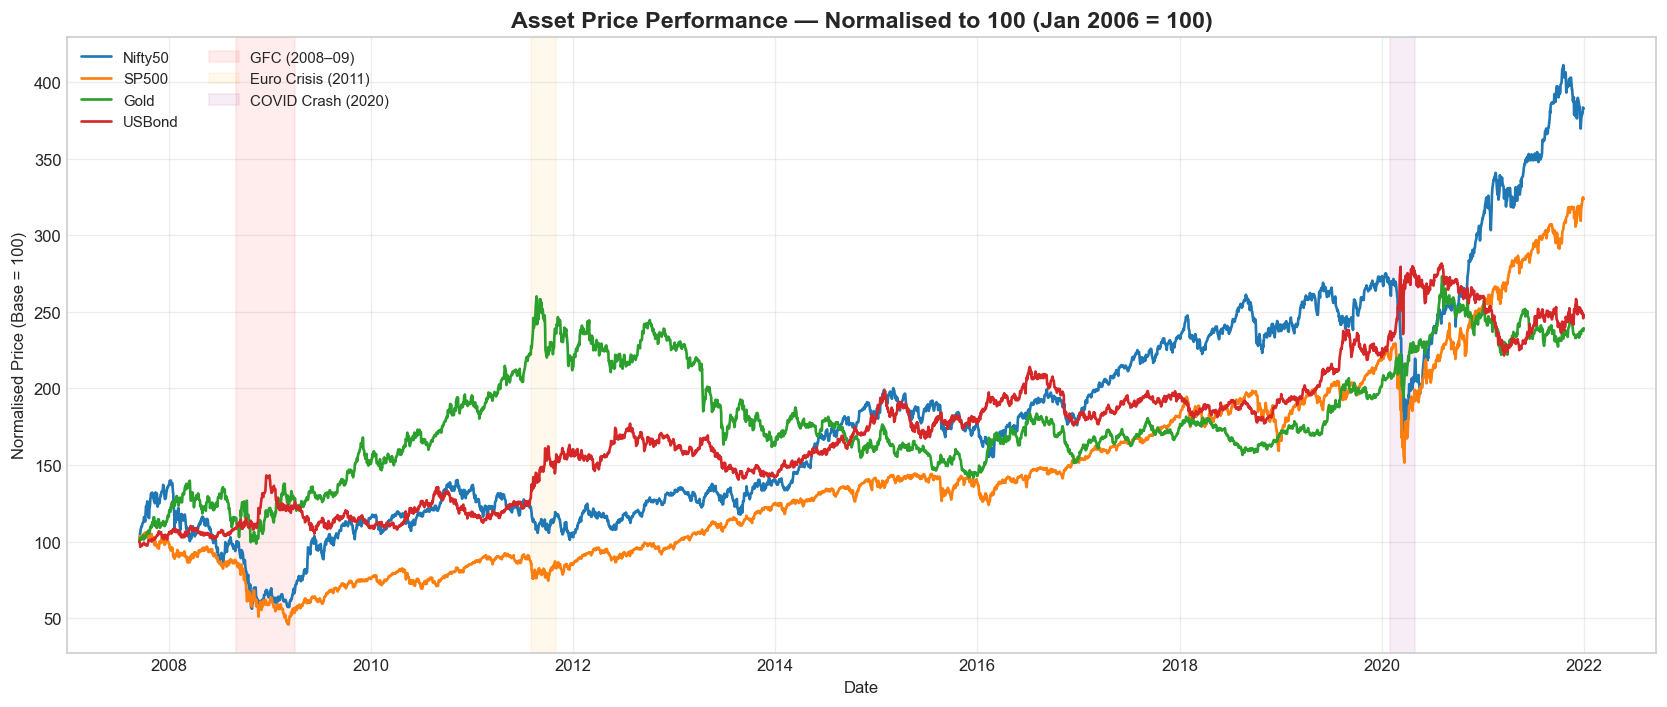

In [5]:
# ── 4.1  Normalised Asset Price Performance ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for col, color in zip(price_cols, ASSET_COLORS):
    series     = combined[col].dropna()
    normalised = series / series.iloc[0] * 100
    ax.plot(normalised.index, normalised, label=col, color=color, linewidth=1.6)

# Shade notable market events
ax.axvspan('2008-09-01', '2009-03-31', alpha=0.07, color='red',    label='GFC (2008–09)')
ax.axvspan('2011-08-01', '2011-10-31', alpha=0.07, color='orange', label='Euro Crisis (2011)')
ax.axvspan('2020-02-01', '2020-04-30', alpha=0.07, color='purple', label='COVID Crash (2020)')

ax.set_title("Asset Price Performance — Normalised to 100 (Jan 2006 = 100)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price (Base = 100)")
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig('01_asset_prices_normalised.png', dpi=150, bbox_inches='tight')
plt.show()


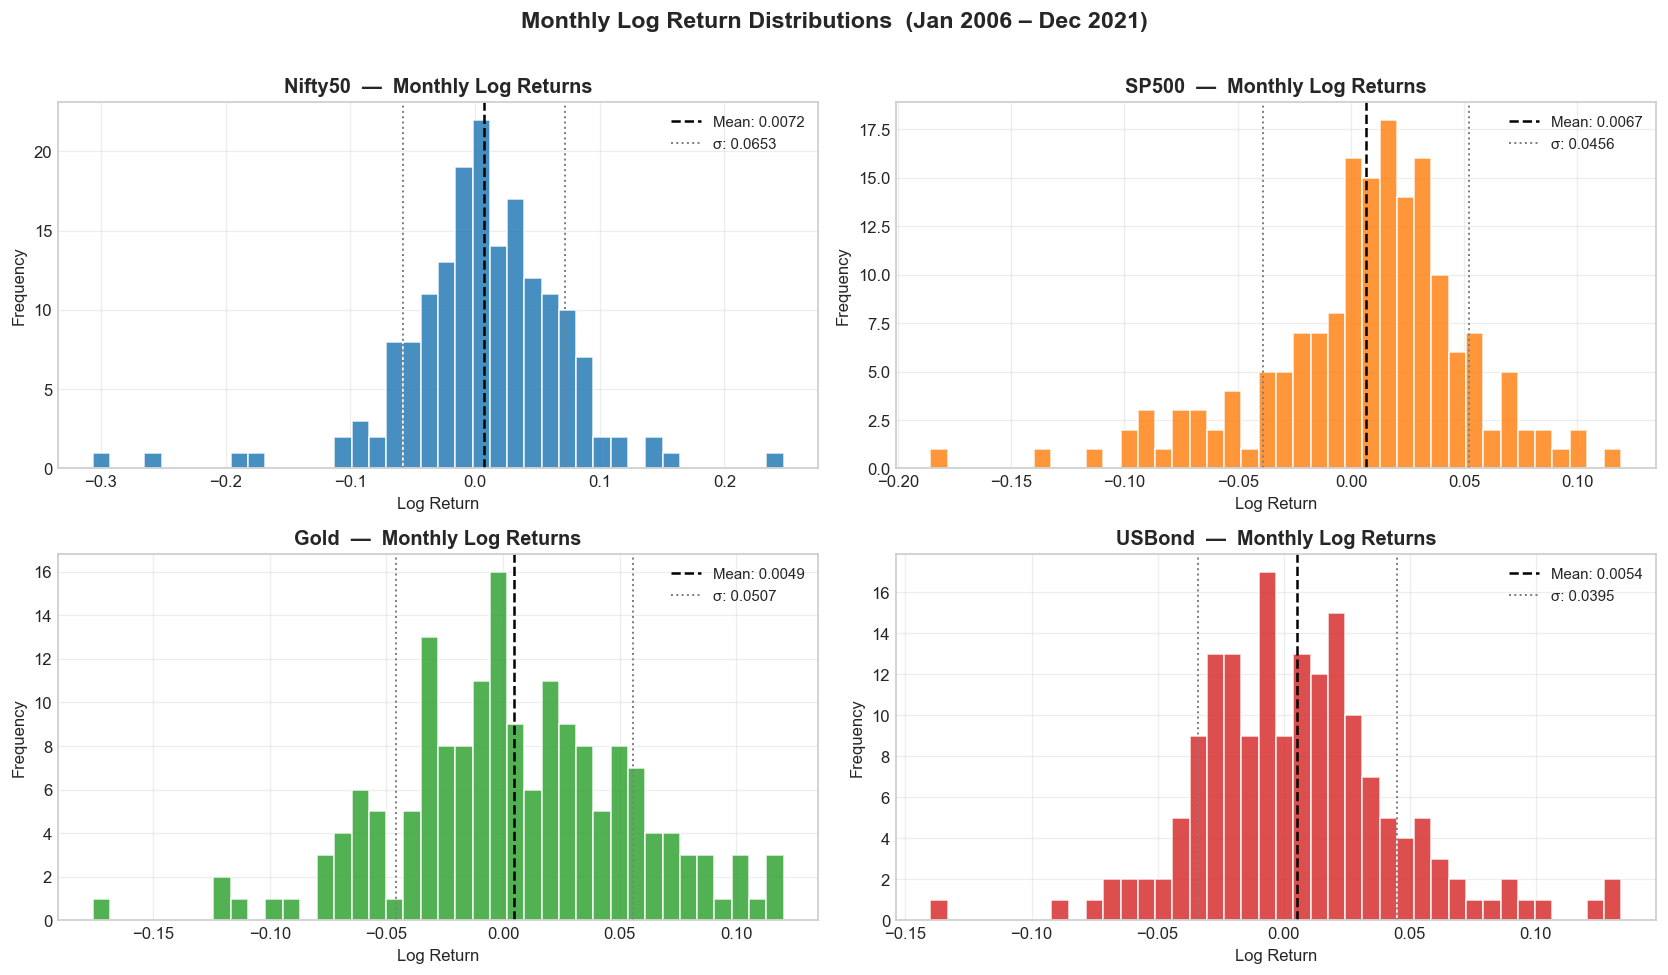

Descriptive Statistics — Monthly Log Returns:


,Nifty50,SP500,Gold,USBond
count,171.000000,171.000000,171.000000,171.000000
mean,0.007201,0.006673,0.004896,0.005413
std,0.065329,0.045576,0.050712,0.039481
min,-0.306665,-0.185636,-0.176017,-0.140076
25%,-0.023978,-0.015154,-0.027788,-0.021226
50%,0.006462,0.013043,0.000536,0.003778
75%,0.044373,0.033542,0.036477,0.026378
max,0.247376,0.119421,0.120326,0.134018
skewness,-0.899264,-0.869655,-0.196567,0.355721
kurtosis,5.108876,1.931191,0.437823,1.660910


In [6]:
# ── 4.2  Monthly Log Return Distributions ───────────────────────────
monthly_prices  = combined[price_cols].resample('ME').last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(price_cols, ASSET_COLORS)):
    ax  = axes[i]
    ret = monthly_returns[col].dropna()
    ax.hist(ret, bins=40, color=color, edgecolor='white', alpha=0.82)
    ax.axvline(ret.mean(), color='black',  linestyle='--', linewidth=1.5,
               label=f'Mean: {ret.mean():.4f}')
    ax.axvline(ret.mean() + ret.std(), color='gray', linestyle=':', linewidth=1.2)
    ax.axvline(ret.mean() - ret.std(), color='gray', linestyle=':', linewidth=1.2,
               label=f'σ: {ret.std():.4f}')
    ax.set_title(f"{col}  —  Monthly Log Returns", fontweight='bold')
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Monthly Log Return Distributions  (Jan 2006 – Dec 2021)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Descriptive Statistics — Monthly Log Returns:")
stats = monthly_returns.describe()
stats.loc['skewness'] = monthly_returns.skew()
stats.loc['kurtosis'] = monthly_returns.kurt()
display(stats)


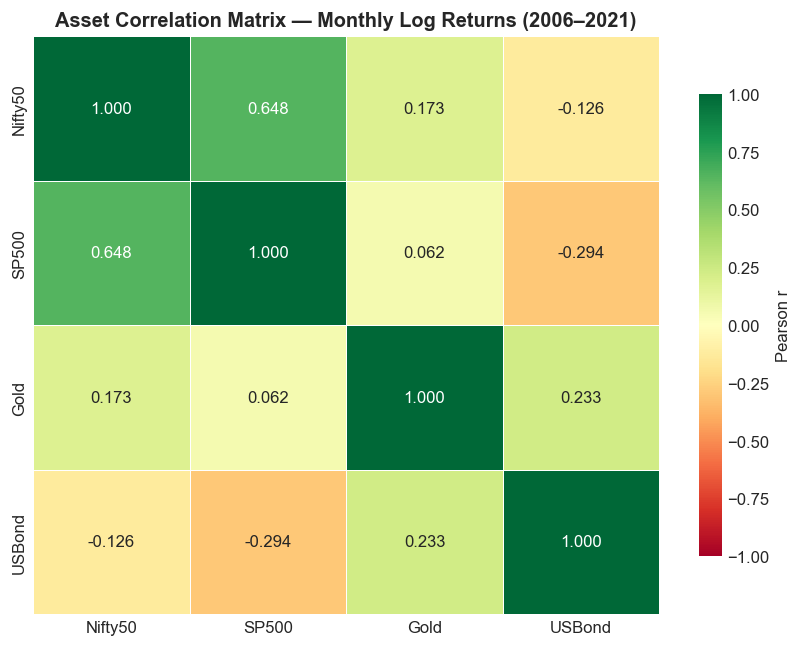


Correlation Commentary:
  Nifty50    vs SP500      : r = +0.648   (strong positive)
  SP500      vs USBond     : r = -0.294   (weak negative)
  Gold       vs USBond     : r = +0.233   (weak positive)
  Nifty50    vs Gold       : r = +0.173   (weak positive)
  Nifty50    vs USBond     : r = -0.126   (weak negative)
  SP500      vs Gold       : r = +0.062   (weak positive)


In [7]:
# ── 4.3  Correlation Heatmap ─────────────────────────────────────────
corr = monthly_returns.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title("Asset Correlation Matrix — Monthly Log Returns (2006–2021)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Commentary:")
pairs = [(c1, c2, corr.loc[c1, c2])
         for i, c1 in enumerate(price_cols)
         for c2 in price_cols[i+1:]]
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, r in pairs:
    direction = "positive" if r > 0 else "negative"
    strength  = ("strong" if abs(r) > 0.5
                 else "moderate" if abs(r) > 0.3
                 else "weak")
    print(f"  {c1:10s} vs {c2:10s} : r = {r:+.3f}   ({strength} {direction})")


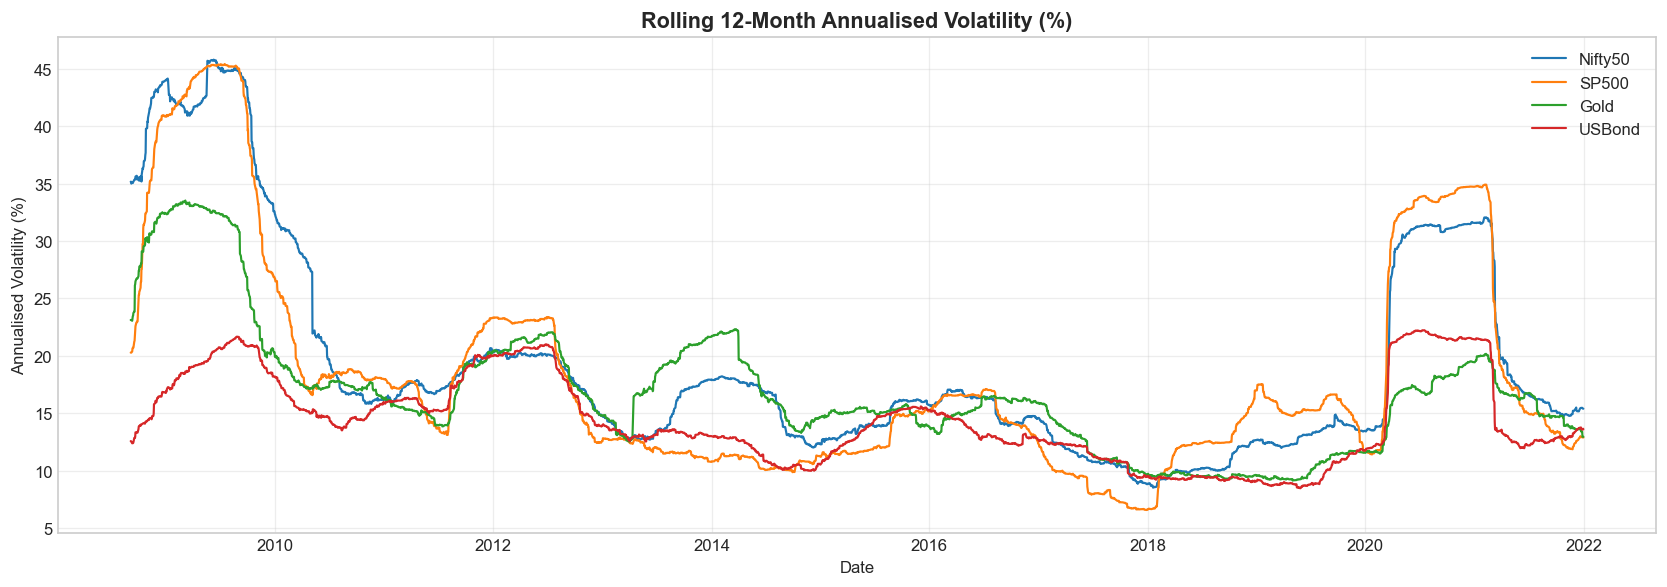

In [8]:
# ── 4.4  Rolling 12-Month Annualised Volatility ──────────────────────
daily_ret   = np.log(combined[price_cols] / combined[price_cols].shift(1))
rolling_vol = daily_ret.rolling(252).std() * np.sqrt(252) * 100   # in %

fig, ax = plt.subplots(figsize=(14, 5))
for col, color in zip(price_cols, ASSET_COLORS):
    ax.plot(rolling_vol.index, rolling_vol[col],
            label=col, color=color, linewidth=1.3)

ax.set_title("Rolling 12-Month Annualised Volatility (%)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Volatility (%)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('04_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5 — Feature Engineering

### Prediction Target
**One-month-ahead log return** for each investable asset:

$$r_{t+1}^{(i)} = \log\left(\frac{P_{t+1}^{(i)}}{P_t^{(i)}}\right)$$

### Feature Set (lagged 1 month to prevent look-ahead bias)

| Feature | Source | Description |
|---|---|---|
| `USDINR_Ret` | Yahoo Finance | Monthly log return of USD/INR rate |
| `US10Y` | Yahoo Finance | US 10-Year Treasury yield level (%) |
| `VIX` | Yahoo Finance | CBOE VIX level |
| `VIX_Change` | Derived | Month-over-month VIX % change |
| `US_FedFunds` | FRED CSV | US Federal Funds Rate (%) |
| `India_RepoRate` | RBI CSV | India RBI Repo Rate (%) |
| `US_GDP_Growth` | FRED CSV | US GDP year-over-year growth (%) |
| `India_GDP_Growth` | World Bank CSV | India GDP year-over-year growth (%) |
| `India_CPI_YoY` | FRED/MOSPI CSV | India CPI year-over-year inflation (%) |

> Features from CSVs that were not found are automatically excluded.

### Train / Test Split
| Split | Period | Months |
|---|---|---|
| **Train** | Jan 2006 – Dec 2018 | ~156 |
| **Test** | Jan 2019 – Dec 2021 | ~36 |


In [9]:
# ── 5.1  Resample to monthly ─────────────────────────────────────────
monthly_prices  = combined[price_cols].resample('ME').last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1))

all_macro_cols  = [c for c in combined.columns if c not in price_cols]
monthly_macro   = combined[all_macro_cols].resample('ME').last()

# ── 5.2  Derived features ────────────────────────────────────────────
# USD/INR monthly log return
monthly_macro['USDINR_Ret'] = np.log(
    monthly_macro['USDINR'] / monthly_macro['USDINR'].shift(1))

# VIX change
monthly_macro['VIX_Change'] = monthly_macro['VIX'].pct_change()

# GDP growth (YoY = compare with same month previous year = 12-period lag)
if 'US_GDP' in monthly_macro.columns:
    monthly_macro['US_GDP_Growth']    = monthly_macro['US_GDP'].pct_change(12)   * 100
if 'India_GDP' in monthly_macro.columns:
    monthly_macro['India_GDP_Growth'] = monthly_macro['India_GDP'].pct_change(12) * 100

# CPI YoY inflation
if 'India_CPI' in monthly_macro.columns:
    monthly_macro['India_CPI_YoY'] = monthly_macro['India_CPI'].pct_change(12) * 100

# ── 5.3  Select available feature columns ────────────────────────────
FEATURE_CANDIDATES = [
    'USDINR_Ret', 'US10Y', 'VIX', 'VIX_Change',
    'US_FedFunds', 'India_RepoRate',
    'US_GDP_Growth', 'India_GDP_Growth', 'India_CPI_YoY'
]
feature_cols = [
    f for f in FEATURE_CANDIDATES
    if f in monthly_macro.columns
    and monthly_macro[f].notna().mean() > 0.50   # at least 50% coverage
]

features = monthly_macro[feature_cols]

print(f"Selected features ({len(feature_cols)}):")
for f in feature_cols:
    print(f"  {f:25s}  coverage={features[f].notna().mean():.1%}")

# ── 5.4  Lag by 1 month (no look-ahead bias) ─────────────────────────
features_lagged = features.shift(1)

# ── 5.5  Assemble ML dataset ─────────────────────────────────────────
ml_data = pd.concat([monthly_returns, features_lagged], axis=1).dropna()

print(f"\nML dataset : {ml_data.shape[0]} months × {ml_data.shape[1]} columns")
print(f"Date range : {ml_data.index[0].date()} → {ml_data.index[-1].date()}")
display(ml_data.head(3))


Selected features (4):
  USDINR_Ret                 coverage=99.4%
  US10Y                      coverage=100.0%
  VIX                        coverage=100.0%
  VIX_Change                 coverage=99.4%

ML dataset : 170 months × 8 columns
Date range : 2007-11-30 → 2021-12-31


,Nifty50,SP500,Gold,USBond,USDINR_Ret,US10Y,VIX,VIX_Change
Date,,,,,,,,
2007-11-30,-0.023648,-0.045043,-0.016674,0.052130,-0.010184,4.475000,18.530001,0.029444
2007-12-31,0.063182,-0.008666,0.064361,-0.006297,0.007148,3.972000,22.870001,0.234215
2008-01-31,-0.178040,-0.063114,0.102932,0.020742,-0.005337,4.035000,22.500000,-0.016178


In [10]:
# ── 5.6  Train / Test split ──────────────────────────────────────────
train = ml_data.loc[:TRAIN_END]
test  = ml_data.loc[TEST_START:]

X_train = train[feature_cols].values
X_test  = test[feature_cols].values

print(f"Train : {len(train)} months   ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  : {len(test)}  months   ({test.index[0].date()} → {test.index[-1].date()})")
print(f"Features : {len(feature_cols)}")

# Per-asset target vectors
targets = {
    col: {'y_train': train[col].values,
          'y_test' : test[col].values}
    for col in price_cols
}


Train : 134 months   (2007-11-30 → 2018-12-31)
Test  : 36  months   (2019-01-31 → 2021-12-31)
Features : 4


---
## Section 6 — Supervised Return Prediction

We train four model families to predict **one-month-ahead log returns** for each asset.

| # | Model | Key property |
|---|---|---|
| 1 | **Linear Regression** | Linear baseline; interpretable coefficients |
| 2 | **SVR (RBF kernel)** | Non-linear via kernel trick; uses ε-insensitive loss |
| 3 | **Random Forest** | Ensemble of decision trees; robust to outliers |
| 4 | **Gradient Boosting** | Sequential boosting; typically state-of-the-art on tabular data |

**Evaluation metrics:**

| Metric | What it measures |
|---|---|
| RMSE | Root mean squared error — penalises large deviations |
| MAE | Mean absolute error — more robust to outliers than RMSE |
| R² | Fraction of variance in returns explained by the model |
| Directional Accuracy | % of months where the model correctly predicts up vs. down |


In [11]:
def fit_and_evaluate(model_name, model, X_tr, y_tr, X_te, y_te,
                     asset, scale=False):
    """
    Fit a model, evaluate on train and test, return (metrics_dict, test_predictions, fitted_model).
    scale=True applies StandardScaler (required for LR and SVR; irrelevant for trees).
    """
    if scale:
        sc = StandardScaler()
        X_tr_ = sc.fit_transform(X_tr)
        X_te_ = sc.transform(X_te)
    else:
        X_tr_, X_te_ = X_tr, X_te

    model.fit(X_tr_, y_tr)
    yp_tr = model.predict(X_tr_)
    yp_te = model.predict(X_te_)

    dir_acc = np.mean(np.sign(yp_te) == np.sign(y_te))

    metrics = {
        'Asset'        : asset,
        'Model'        : model_name,
        'Train_RMSE'   : np.sqrt(mean_squared_error(y_tr, yp_tr)),
        'Test_RMSE'    : np.sqrt(mean_squared_error(y_te, yp_te)),
        'Train_R2'     : r2_score(y_tr, yp_tr),
        'Test_R2'      : r2_score(y_te, yp_te),
        'Test_MAE'     : mean_absolute_error(y_te, yp_te),
        'Dir_Accuracy' : dir_acc,
    }
    preds = pd.Series(yp_te, index=test.index, name=model_name)
    return metrics, preds, model

# Containers
all_metrics     = []
all_predictions = {asset: {} for asset in price_cols}
all_models      = {asset: {} for asset in price_cols}

print("✓  Evaluation helper defined.")


✓  Evaluation helper defined.


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MODEL 1 — LINEAR REGRESSION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("  MODEL 1 : LINEAR REGRESSION")
print("=" * 65)

for asset in price_cols:
    m, preds, mdl = fit_and_evaluate(
        'LinearRegression', LinearRegression(),
        X_train, targets[asset]['y_train'],
        X_test,  targets[asset]['y_test'],
        asset, scale=True
    )
    all_metrics.append(m)
    all_predictions[asset]['LinearRegression'] = preds
    all_models[asset]['LinearRegression']      = mdl
    print(f"  {asset:10s}  Test RMSE={m['Test_RMSE']:.5f}  "
          f"R²={m['Test_R2']:+.4f}  Dir.Acc={m['Dir_Accuracy']:.1%}")

# Print coefficients
print("\nModel Coefficients (standardised features):")
for asset in price_cols:
    mdl  = all_models[asset]['LinearRegression']
    coef = pd.Series(mdl.coef_, index=feature_cols, name=asset)
    print(f"\n  {asset}:")
    display(coef.to_frame().T)


  MODEL 1 : LINEAR REGRESSION
  Nifty50     Test RMSE=0.06699  R²=-0.0869  Dir.Acc=58.3%
  SP500       Test RMSE=0.04949  R²=+0.0063  Dir.Acc=69.4%
  Gold        Test RMSE=0.04410  R²=-0.1158  Dir.Acc=41.7%
  USBond      Test RMSE=0.03903  R²=-0.0224  Dir.Acc=55.6%

Model Coefficients (standardised features):

  Nifty50:


,USDINR_Ret,US10Y,VIX,VIX_Change
Nifty50,-0.007137,-0.015261,0.010966,-0.003213



  SP500:


,USDINR_Ret,US10Y,VIX,VIX_Change
SP500,-0.001902,-0.011736,0.002614,-0.005933



  Gold:


,USDINR_Ret,US10Y,VIX,VIX_Change
Gold,-0.007536,0.005039,0.007613,-0.000382



  USBond:


,USDINR_Ret,US10Y,VIX,VIX_Change
USBond,0.004901,0.007546,0.000614,0.004309


In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MODEL 2 — SUPPORT VECTOR REGRESSION  (RBF kernel)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("  MODEL 2 : SUPPORT VECTOR REGRESSION  (kernel=rbf, C=1, ε=0.005)")
print("=" * 65)

for asset in price_cols:
    m, preds, mdl = fit_and_evaluate(
        'SVR',
        SVR(kernel='rbf', C=1.0, epsilon=0.005, gamma='scale'),
        X_train, targets[asset]['y_train'],
        X_test,  targets[asset]['y_test'],
        asset, scale=True     # SVR requires feature standardisation
    )
    all_metrics.append(m)
    all_predictions[asset]['SVR'] = preds
    all_models[asset]['SVR']      = mdl
    print(f"  {asset:10s}  Test RMSE={m['Test_RMSE']:.5f}  "
          f"R²={m['Test_R2']:+.4f}  Dir.Acc={m['Dir_Accuracy']:.1%}")

print("\nNote: SVR does not expose feature coefficients in the original space.")
print("      Feature importance is examined via Random Forest and Gradient")
print("      Boosting in the next two cells.")


  MODEL 2 : SUPPORT VECTOR REGRESSION  (kernel=rbf, C=1, ε=0.005)
  Nifty50     Test RMSE=0.07847  R²=-0.4913  Dir.Acc=75.0%
  SP500       Test RMSE=0.05982  R²=-0.4523  Dir.Acc=58.3%
  Gold        Test RMSE=0.04076  R²=+0.0467  Dir.Acc=61.1%
  USBond      Test RMSE=0.05188  R²=-0.8065  Dir.Acc=58.3%

Note: SVR does not expose feature coefficients in the original space.
      Feature importance is examined via Random Forest and Gradient
      Boosting in the next two cells.


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MODEL 3 — RANDOM FOREST
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("  MODEL 3 : RANDOM FOREST  (n_estimators=200, max_depth=5)")
print("=" * 65)

for asset in price_cols:
    m, preds, mdl = fit_and_evaluate(
        'RandomForest',
        RandomForestRegressor(n_estimators=200, max_depth=5,
                              min_samples_leaf=3, n_jobs=-1,
                              random_state=RANDOM_STATE),
        X_train, targets[asset]['y_train'],
        X_test,  targets[asset]['y_test'],
        asset, scale=False    # decision trees are scale-invariant
    )
    all_metrics.append(m)
    all_predictions[asset]['RandomForest'] = preds
    all_models[asset]['RandomForest']      = mdl
    print(f"  {asset:10s}  Test RMSE={m['Test_RMSE']:.5f}  "
          f"R²={m['Test_R2']:+.4f}  Dir.Acc={m['Dir_Accuracy']:.1%}")


  MODEL 3 : RANDOM FOREST  (n_estimators=200, max_depth=5)


C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\User

  Nifty50     Test RMSE=0.06233  R²=+0.0591  Dir.Acc=72.2%


C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
C:\User

  SP500       Test RMSE=0.05174  R²=-0.0862  Dir.Acc=69.4%
  Gold        Test RMSE=0.04555  R²=-0.1907  Dir.Acc=44.4%
  USBond      Test RMSE=0.04167  R²=-0.1657  Dir.Acc=58.3%


In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MODEL 4 — GRADIENT BOOSTING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("  MODEL 4 : GRADIENT BOOSTING  (n_estimators=200, lr=0.05)")
print("=" * 65)

for asset in price_cols:
    m, preds, mdl = fit_and_evaluate(
        'GradientBoosting',
        GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                   learning_rate=0.05, subsample=0.8,
                                   random_state=RANDOM_STATE),
        X_train, targets[asset]['y_train'],
        X_test,  targets[asset]['y_test'],
        asset, scale=False
    )
    all_metrics.append(m)
    all_predictions[asset]['GradientBoosting'] = preds
    all_models[asset]['GradientBoosting']      = mdl
    print(f"  {asset:10s}  Test RMSE={m['Test_RMSE']:.5f}  "
          f"R²={m['Test_R2']:+.4f}  Dir.Acc={m['Dir_Accuracy']:.1%}")


  MODEL 4 : GRADIENT BOOSTING  (n_estimators=200, lr=0.05)
  Nifty50     Test RMSE=0.06713  R²=-0.0916  Dir.Acc=72.2%
  SP500       Test RMSE=0.05280  R²=-0.1314  Dir.Acc=66.7%
  Gold        Test RMSE=0.05327  R²=-0.6287  Dir.Acc=33.3%
  USBond      Test RMSE=0.05052  R²=-0.7133  Dir.Acc=44.4%


---
## Section 7 — Model Evaluation & Comparison


In [16]:
# ── 7.1  Full Results Table ──────────────────────────────────────────
results_df = pd.DataFrame(all_metrics)

print("=" * 75)
print("  TEST SET PERFORMANCE — ALL MODELS × ALL ASSETS")
print("=" * 75)

for asset in price_cols:
    sub = (results_df[results_df['Asset'] == asset]
           .set_index('Model')
           [['Train_RMSE', 'Test_RMSE', 'Test_MAE', 'Test_R2', 'Dir_Accuracy']])
    print(f"\n{'─'*60}")
    print(f"  {asset}")
    print(f"{'─'*60}")
    display(
        sub.style
           .highlight_min(subset=['Test_RMSE', 'Test_MAE'],   color='#c6efce')
           .highlight_max(subset=['Test_R2', 'Dir_Accuracy'], color='#c6efce')
           .format({'Train_RMSE'   : '{:.5f}', 'Test_RMSE'   : '{:.5f}',
                    'Test_MAE'     : '{:.5f}', 'Test_R2'     : '{:+.4f}',
                    'Dir_Accuracy' : '{:.1%}'})
    )


  TEST SET PERFORMANCE — ALL MODELS × ALL ASSETS

────────────────────────────────────────────────────────────
  Nifty50
────────────────────────────────────────────────────────────


,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Dir_Accuracy
Model,,,,,
LinearRegression,0.06190,0.06699,0.04105,-0.0869,58.3%
SVR,0.03671,0.07847,0.05532,-0.4913,75.0%
RandomForest,0.04572,0.06233,0.03755,+0.0591,72.2%
GradientBoosting,0.01693,0.06713,0.04138,-0.0916,72.2%



────────────────────────────────────────────────────────────
  SP500
────────────────────────────────────────────────────────────


,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Dir_Accuracy
Model,,,,,
LinearRegression,0.04189,0.04949,0.03588,+0.0063,69.4%
SVR,0.02159,0.05982,0.04871,-0.4523,58.3%
RandomForest,0.03035,0.05174,0.04005,-0.0862,69.4%
GradientBoosting,0.01117,0.05280,0.03932,-0.1314,66.7%



────────────────────────────────────────────────────────────
  Gold
────────────────────────────────────────────────────────────


,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Dir_Accuracy
Model,,,,,
LinearRegression,0.05117,0.04410,0.03427,-0.1158,41.7%
SVR,0.03383,0.04076,0.03295,+0.0467,61.1%
RandomForest,0.03832,0.04555,0.03637,-0.1907,44.4%
GradientBoosting,0.01770,0.05327,0.04386,-0.6287,33.3%



────────────────────────────────────────────────────────────
  USBond
────────────────────────────────────────────────────────────


,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Dir_Accuracy
Model,,,,,
LinearRegression,0.03803,0.03903,0.03080,-0.0224,55.6%
SVR,0.02190,0.05188,0.03863,-0.8065,58.3%
RandomForest,0.02824,0.04167,0.03262,-0.1657,58.3%
GradientBoosting,0.00997,0.05052,0.03961,-0.7133,44.4%


C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:108: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000015AEB21F970>
  def __init__(self, func, args, kwds):
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:108: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000015AEB21FC40>
  def __init__(self, func, args, kwds):
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:108: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000015AB2907100>
  def __init__(self, func, args, kwds):
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:108: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000015AB2907010>
  def __init__(self, func, args, kwds):
C:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:108: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000015AB2906F20>
  def

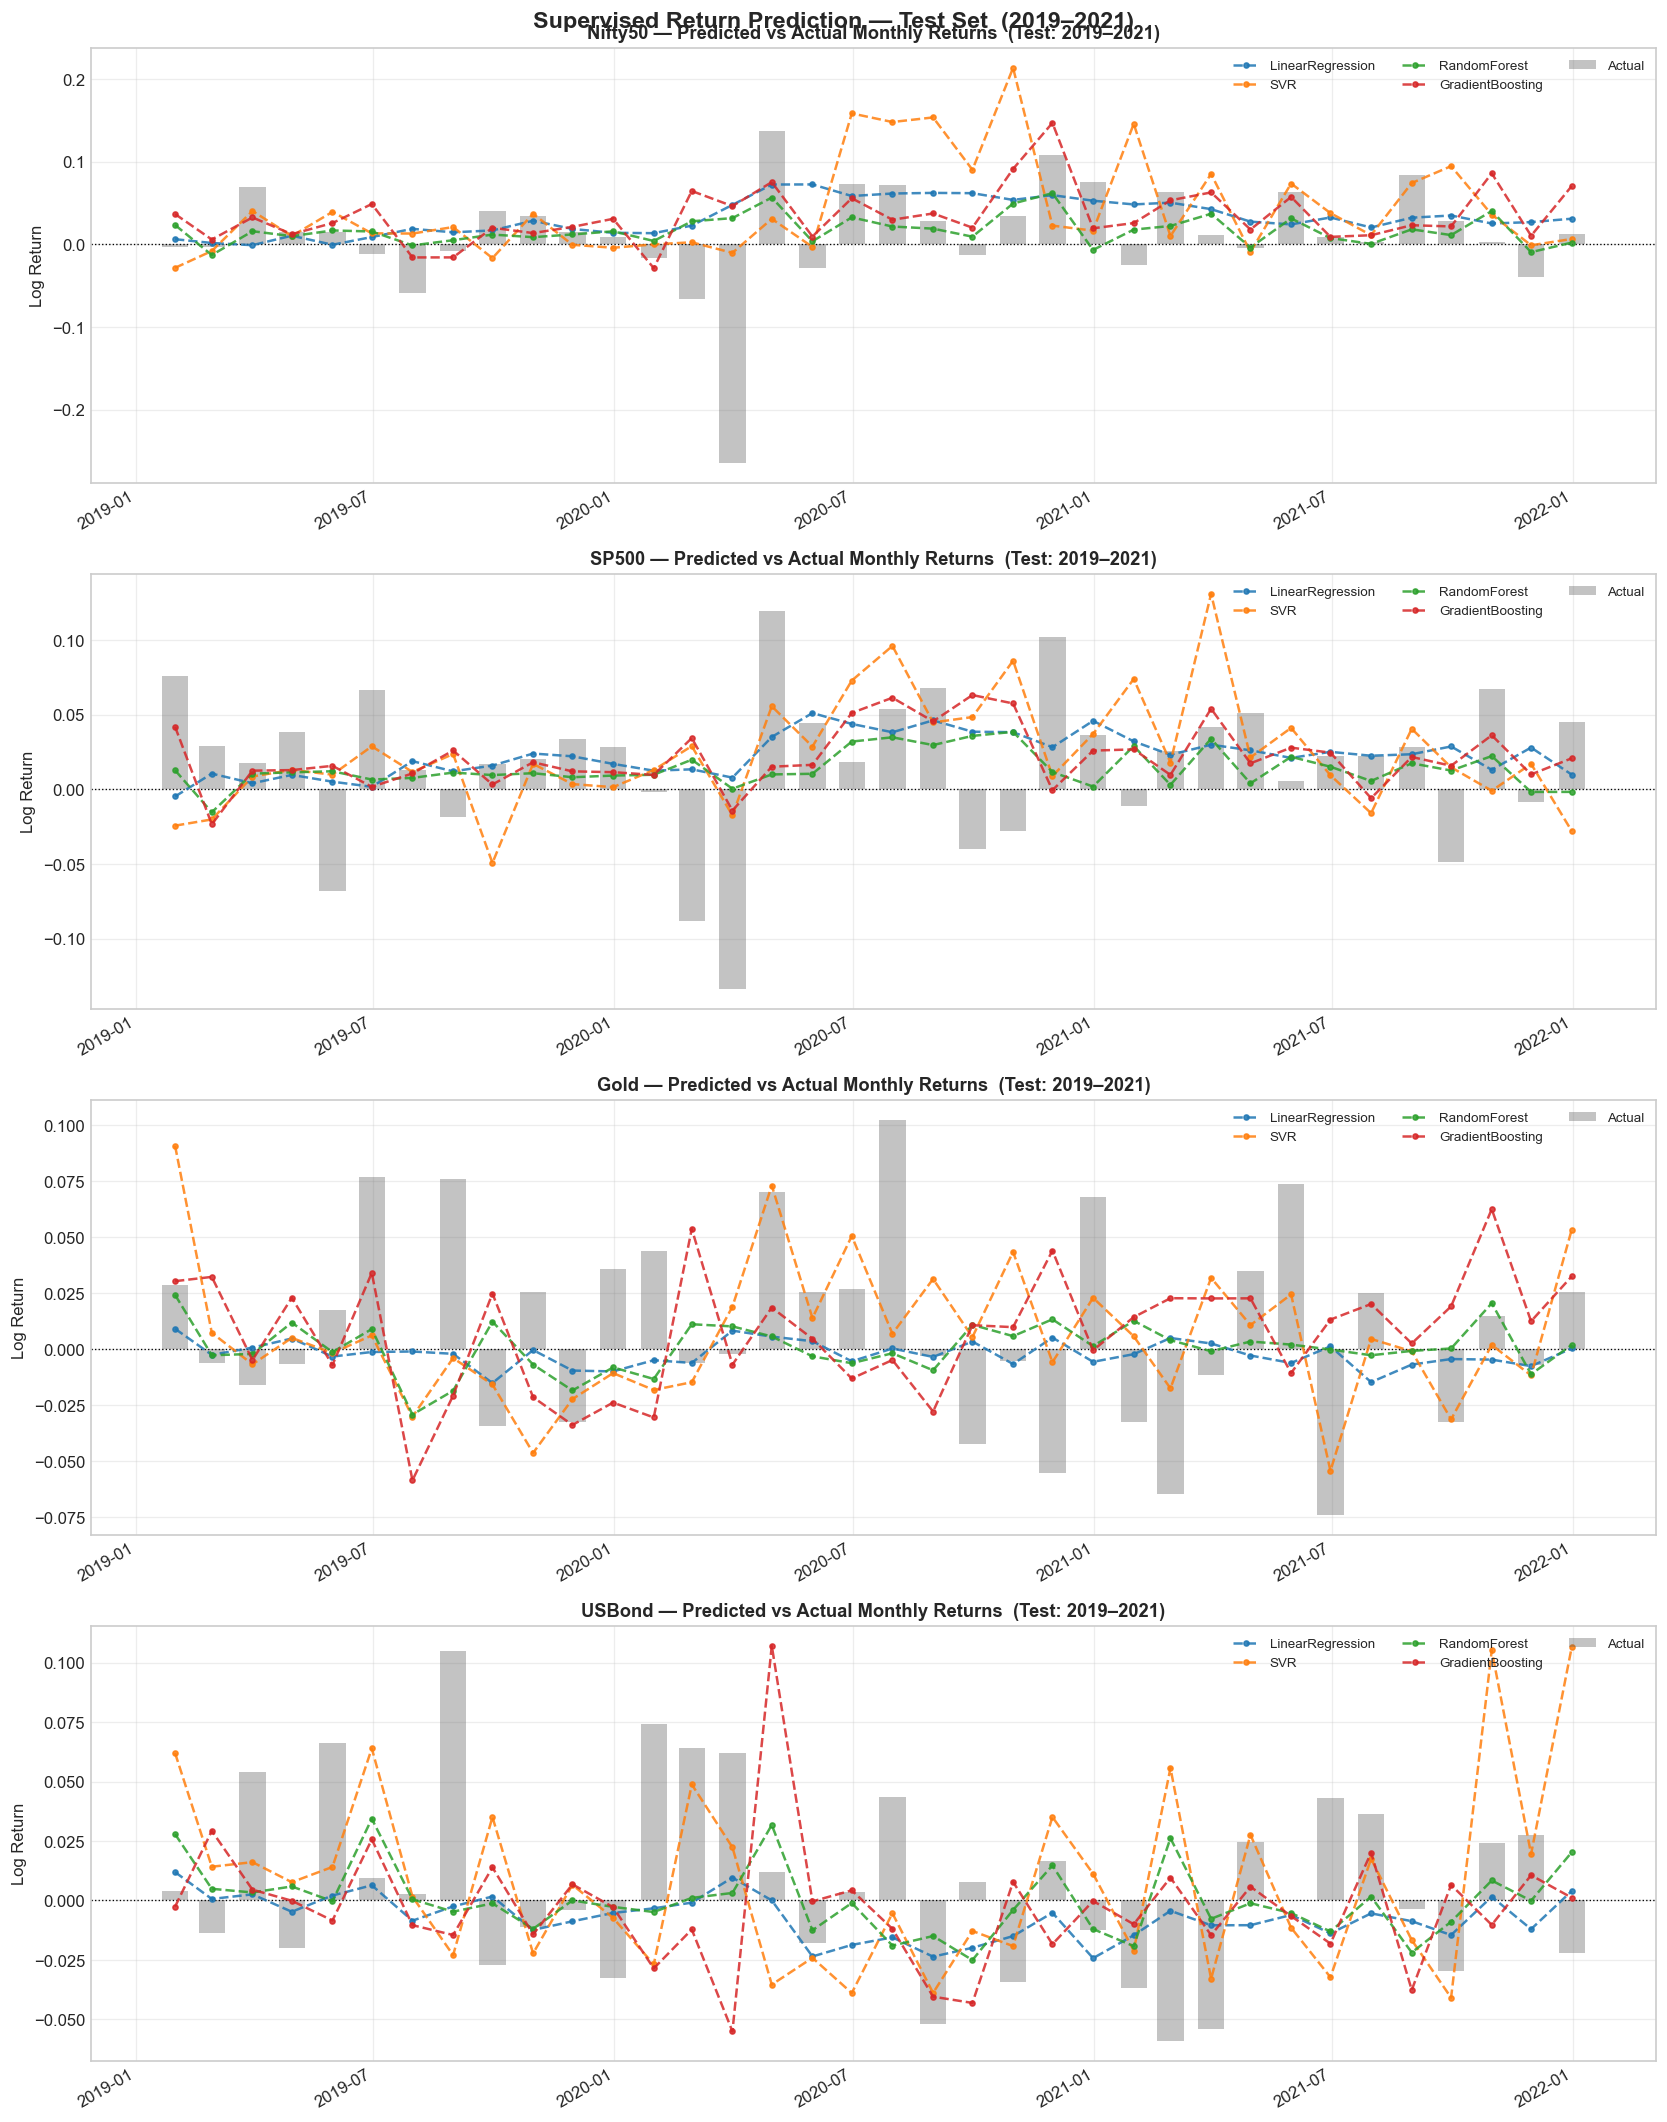

In [17]:
# ── 7.2  Predicted vs Actual Returns — Test Set ──────────────────────
MODEL_COLORS = {
    'LinearRegression' : '#1f77b4',
    'SVR'              : '#ff7f0e',
    'RandomForest'     : '#2ca02c',
    'GradientBoosting' : '#d62728',
}

fig, axes = plt.subplots(len(price_cols), 1,
                          figsize=(14, 4.5 * len(price_cols)))
if len(price_cols) == 1:
    axes = [axes]

for ax, asset in zip(axes, price_cols):
    actual = targets[asset]['y_test']
    ax.bar(test.index, actual, width=20,
           color='#555555', alpha=0.35, label='Actual', zorder=2)

    for mname, color in MODEL_COLORS.items():
        if mname in all_predictions[asset]:
            ax.plot(test.index, all_predictions[asset][mname],
                    color=color, linewidth=1.5, marker='o', markersize=3,
                    linestyle='--', label=mname, alpha=0.85, zorder=3)

    ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
    ax.set_title(f"{asset} — Predicted vs Actual Monthly Returns  (Test: 2019–2021)",
                 fontweight='bold', fontsize=11)
    ax.set_ylabel("Log Return")
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle("Supervised Return Prediction — Test Set  (2019–2021)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()


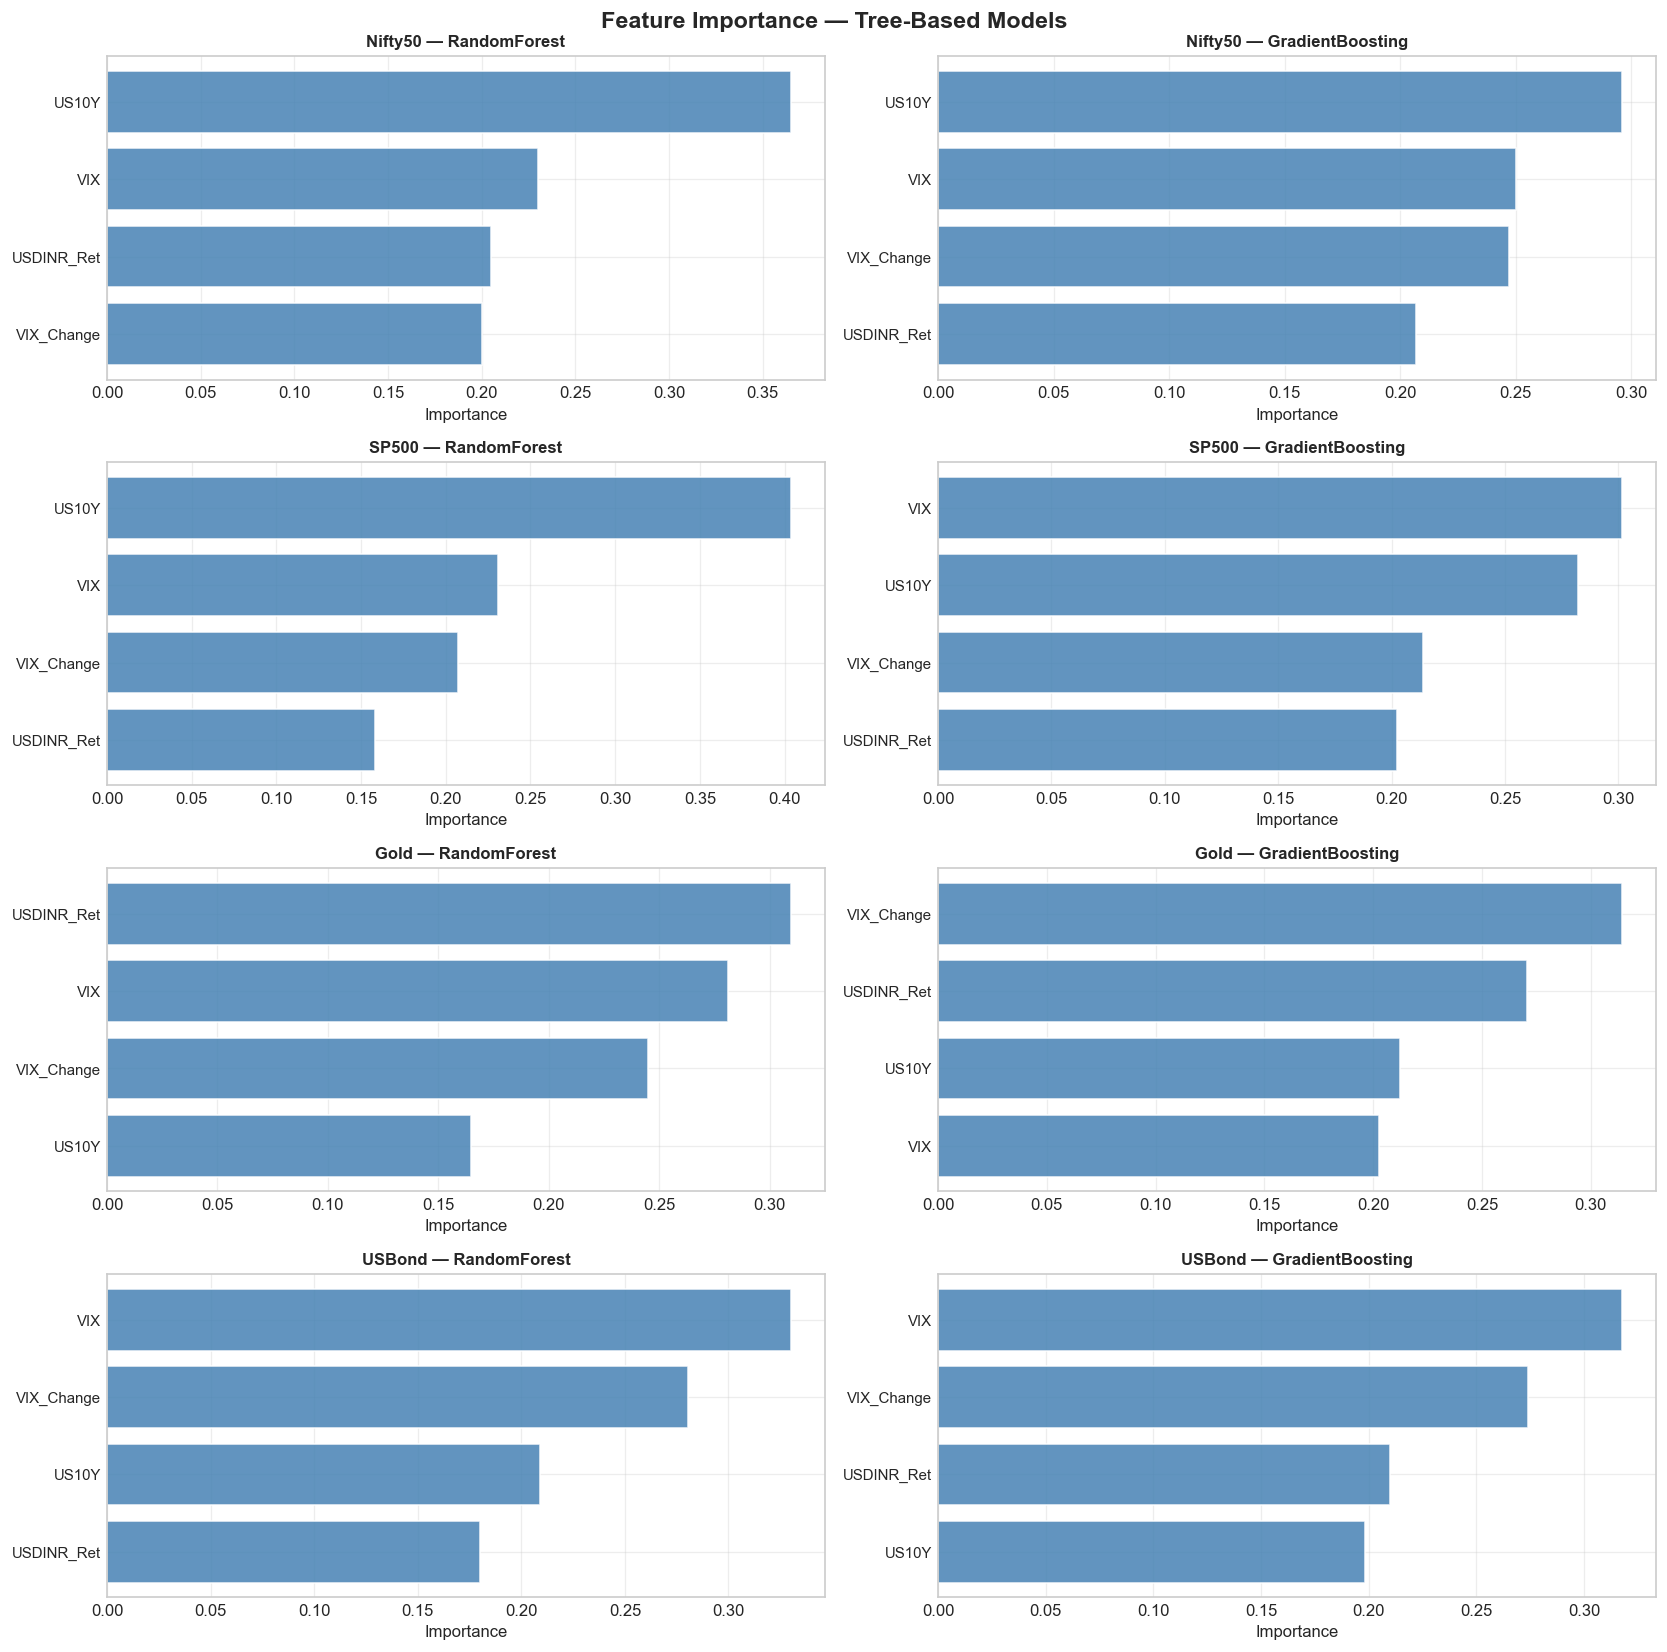

In [18]:
# ── 7.3  Feature Importance — Tree-Based Models ─────────────────────
tree_models = ['RandomForest', 'GradientBoosting']
n_assets    = len(price_cols)

fig, axes = plt.subplots(n_assets, 2,
                          figsize=(14, max(4, 3.5 * n_assets)))
if n_assets == 1:
    axes = [axes]

for row, asset in enumerate(price_cols):
    for col_idx, mname in enumerate(tree_models):
        ax  = axes[row][col_idx]
        mdl = all_models[asset][mname]
        imp = mdl.feature_importances_
        idx = np.argsort(imp)   # ascending for horizontal bar

        ax.barh(range(len(feature_cols)),
                imp[idx], color='steelblue',
                edgecolor='white', alpha=0.85)
        ax.set_yticks(range(len(feature_cols)))
        ax.set_yticklabels([feature_cols[i] for i in idx], fontsize=9)
        ax.set_xlabel("Importance")
        ax.set_title(f"{asset} — {mname}", fontweight='bold', fontsize=10)

plt.suptitle("Feature Importance — Tree-Based Models",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── 7.4  Best Model per Asset ────────────────────────────────────────
best = (results_df
        .loc[results_df.groupby('Asset')['Test_RMSE'].idxmin()]
        .set_index('Asset')
        [['Model', 'Test_RMSE', 'Test_R2', 'Dir_Accuracy']])

print("=" * 65)
print("  BEST MODEL PER ASSET  (minimum Test RMSE on 2019–2021)")
print("=" * 65)
display(
    best.style.format({
        'Test_RMSE'    : '{:.5f}',
        'Test_R2'      : '{:+.4f}',
        'Dir_Accuracy' : '{:.1%}'
    })
)
print("\n→ These predicted returns will feed into the Markowitz")
print("  mean-variance optimizer as the expected return vector μ")
print("  in Phase 3 (Portfolio Optimization).")


  BEST MODEL PER ASSET  (minimum Test RMSE on 2019–2021)


,Model,Test_RMSE,Test_R2,Dir_Accuracy
Asset,,,,
Gold,SVR,0.04076,+0.0467,61.1%
Nifty50,RandomForest,0.06233,+0.0591,72.2%
SP500,LinearRegression,0.04949,+0.0063,69.4%
USBond,LinearRegression,0.03903,-0.0224,55.6%



→ These predicted returns will feed into the Markowitz
  mean-variance optimizer as the expected return vector μ
  in Phase 3 (Portfolio Optimization).


In [20]:
# ── Save all outputs for downstream phases ───────────────────────────
combined.to_csv('data_daily_combined.csv')
print("✓  data_daily_combined.csv     — full daily dataset (prices + macro)")

ml_data.to_csv('data_monthly_ml.csv')
print("✓  data_monthly_ml.csv         — monthly ML-ready dataset")

# Predictions on test set
pred_series = []
for asset in price_cols:
    actual = pd.Series(targets[asset]['y_test'],
                       index=test.index, name=f'{asset}_actual')
    pred_series.append(actual)
    for mname in ['LinearRegression', 'SVR', 'RandomForest', 'GradientBoosting']:
        if mname in all_predictions[asset]:
            pred_series.append(
                all_predictions[asset][mname].rename(f'{asset}_{mname}'))

pd.concat(pred_series, axis=1).to_csv('predictions_test_set.csv')
print("✓  predictions_test_set.csv    — all model predictions (test set)")

results_df.to_csv('model_metrics.csv', index=False)
print("✓  model_metrics.csv           — RMSE / R² / Dir.Acc all models")


✓  data_daily_combined.csv     — full daily dataset (prices + macro)
✓  data_monthly_ml.csv         — monthly ML-ready dataset
✓  predictions_test_set.csv    — all model predictions (test set)
✓  model_metrics.csv           — RMSE / R² / Dir.Acc all models


---
## Section 8 — Lagged vs Contemporaneous (No-Lag) Comparison

**Purpose:** Test whether lagged (t−1) macro features genuinely *predict* returns,
or whether they merely *correlate* contemporaneously. If no-lag models perform
significantly better, it suggests macro data is priced in within the same month.

- **Lagged (lag=1):** Macro at t−1 predicts return at t — realistic, tradeable
- **Contemporaneous (lag=0):** Macro at t vs return at t — look-ahead bias, NOT tradeable


In [ ]:
# ============================================================
# SECTION 8 -- LAGGED vs CONTEMPORANEOUS COMPARISON
# All 4 models, lag=0 vs lag=1, same features
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

# -- Build contemporaneous (no-lag) dataset --------------------
features_nolag = features  # no .shift(1)
ml_data_nolag  = pd.concat([monthly_returns, features_nolag], axis=1).dropna()

train_nl = ml_data_nolag.loc[:TRAIN_END]
test_nl  = ml_data_nolag.loc[TEST_START:]

X_train_nl = train_nl[feature_cols].values
X_test_nl  = test_nl[feature_cols].values

targets_nl = {
    col: {'y_train': train_nl[col].values,
          'y_test' : test_nl[col].values}
    for col in price_cols
}

print(f'Contemporaneous dataset: {len(ml_data_nolag)} months')
print(f'Train: {len(train_nl)}  Test: {len(test_nl)}')
print(f'Features: {feature_cols}\n')

# -- Define models (same configs as Section 6) -----------------
MODEL_DEFS = [
    ('LinearRegression', lambda: LinearRegression(), True),
    ('SVR', lambda: SVR(kernel='rbf', C=1.0, epsilon=0.005, gamma='scale'), True),
    ('RandomForest', lambda: RandomForestRegressor(
        n_estimators=200, max_depth=5, min_samples_leaf=3,
        n_jobs=-1, random_state=42), False),
    ('GradientBoosting', lambda: GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=3, random_state=42), False),
]

# -- Run all models with no lag --------------------------------
nolag_metrics = []
for model_name, model_fn, scale in MODEL_DEFS:
    for asset in price_cols:
        m, preds, mdl = fit_and_evaluate(
            model_name, model_fn(),
            X_train_nl, targets_nl[asset]['y_train'],
            X_test_nl,  targets_nl[asset]['y_test'],
            asset, scale=scale
        )
        nolag_metrics.append(m)

nolag_df = pd.DataFrame(nolag_metrics)

# -- Merge lagged results (from Section 6) --------------------
lagged_df = results_df.copy()
lagged_df['Lag'] = 'Lagged (t-1)'
nolag_df['Lag']  = 'Contemp (t)'

comparison = pd.concat([lagged_df, nolag_df], ignore_index=True)

# -- Print master comparison table -----------------------------
print('=' * 85)
print('  LAGGED vs CONTEMPORANEOUS -- ALL MODELS, ALL ASSETS')
print('=' * 85)
print(f"\n  {'Asset':<10} {'Model':<20} {'Lag':<14} "
      f"{'Test RMSE':>10} {'Test R2':>9} {'Dir Acc':>9}")
print(f"  {'---'*25}")

for asset in price_cols:
    for model_name, _, _ in MODEL_DEFS:
        for lag_label in ['Lagged (t-1)', 'Contemp (t)']:
            row = comparison[
                (comparison['Asset'] == asset) &
                (comparison['Model'] == model_name) &
                (comparison['Lag']   == lag_label)
            ]
            if len(row) > 0:
                r = row.iloc[0]
                print(f"  {r['Asset']:<10} {r['Model']:<20} {lag_label:<14} "
                      f"{r['Test_RMSE']:>10.5f} {r['Test_R2']:>9.4f} "
                      f"{r['Dir_Accuracy']:>9.1%}")
        print()

# -- Summary: which is better per asset per model? -------------
print('\n' + '=' * 85)
print('  WINNER PER ASSET/MODEL (by Test RMSE)')
print('=' * 85)
print(f"\n  {'Asset':<10} {'Model':<20} {'Lag RMSE':>10} {'NoLag RMSE':>12} "
      f"{'Lag DirAcc':>10} {'NoLag DirAcc':>13} {'Better':>8}")
print(f"  {'---'*27}")

lag_wins = 0
nolag_wins = 0
for asset in price_cols:
    for model_name, _, _ in MODEL_DEFS:
        lag_row = comparison[
            (comparison['Asset'] == asset) &
            (comparison['Model'] == model_name) &
            (comparison['Lag']   == 'Lagged (t-1)')
        ]
        nl_row = comparison[
            (comparison['Asset'] == asset) &
            (comparison['Model'] == model_name) &
            (comparison['Lag']   == 'Contemp (t)')
        ]
        if len(lag_row) > 0 and len(nl_row) > 0:
            lr = lag_row.iloc[0]
            nr = nl_row.iloc[0]
            better = 'Lag' if lr['Test_RMSE'] < nr['Test_RMSE'] else 'NoLag'
            if better == 'Lag':
                lag_wins += 1
            else:
                nolag_wins += 1
            print(f"  {asset:<10} {model_name:<20} "
                  f"{lr['Test_RMSE']:>10.5f} {nr['Test_RMSE']:>12.5f} "
                  f"{lr['Dir_Accuracy']:>10.1%} {nr['Dir_Accuracy']:>13.1%} "
                  f"{better:>8}")

print(f"\n  Score: Lagged wins {lag_wins} / {lag_wins+nolag_wins}, "
      f"Contemporaneous wins {nolag_wins} / {lag_wins+nolag_wins}")

# -- Visualization: grouped bar chart -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Lagged (t-1) vs Contemporaneous (t) Macro Features',
             fontsize=14, fontweight='bold')

for ax_idx, metric, label in [(0, 'Test_R2', 'Test R\u00b2'),
                               (1, 'Dir_Accuracy', 'Directional Accuracy')]:
    ax = axes[ax_idx]
    x_labels = []
    lag_vals = []
    nolag_vals = []
    for asset in price_cols:
        for model_name, _, _ in MODEL_DEFS:
            x_labels.append(f'{asset}\n{model_name[:6]}')
            lr = comparison[(comparison['Asset']==asset) &
                           (comparison['Model']==model_name) &
                           (comparison['Lag']=='Lagged (t-1)')]
            nr = comparison[(comparison['Asset']==asset) &
                           (comparison['Model']==model_name) &
                           (comparison['Lag']=='Contemp (t)')]
            lag_vals.append(lr.iloc[0][metric] if len(lr)>0 else 0)
            nolag_vals.append(nr.iloc[0][metric] if len(nr)>0 else 0)
    x = np.arange(len(x_labels))
    w = 0.35
    ax.bar(x - w/2, lag_vals,   w, label='Lagged (t-1)', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, nolag_vals, w, label='Contemp (t)',  color='darkorange', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha='right')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=9)
    if metric == 'Test_R2':
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    else:
        ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('section8_lag_vs_nolag.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSection 8 complete -- lag vs no-lag comparison saved.')


---
## Phase 1 Summary

| Component | Status | Key Output |
|---|---|---|
| Yahoo Finance download (daily) | ✓ | `data_daily_combined.csv` |
| CSV macro indicators | ✓ | Merged into combined dataset |
| Preprocessing & forward-fill | ✓ | `data_monthly_ml.csv` |
| EDA (4 plots) | ✓ | PNG files |
| Linear Regression | ✓ | `model_metrics.csv` |
| SVR (RBF kernel) | ✓ | `model_metrics.csv` |
| Random Forest | ✓ | `model_metrics.csv` |
| Gradient Boosting | ✓ | `model_metrics.csv` |
| Predicted returns (test set) | ✓ | `predictions_test_set.csv` |

**Next phases:**
- **Phase 2 (Regime Detection):** PCA dimensionality reduction + GMM clustering on macro feature space to identify market regimes (Growth / Inflationary / Risk-Off / Stagflation)  
- **Phase 3 (Optimization):** Feed best-model predicted returns as μ into constrained Markowitz mean-variance optimizer via `cvxpy`  
- **Phase 4 (Backtesting):** Walk-forward backtest vs equal-weight and classical Markowitz baselines; evaluate Sharpe ratio, cumulative return, max drawdown


---
## Phase 3 — PCA + GMM Regime Detection & Regime-Aware Portfolio Optimization

**Pipeline:**
1. Engineer 5 macro features (CPI, PMI, Repo Rate, M2 growth, India VIX)
2. PCA dimensionality reduction (≥80% variance retained)
3. GMM clustering (k=4) to detect macro regimes
4. Label regimes: Growth, Inflationary, Risk-Off, Stagflation
5. Regime-conditional allocation bounds
6. Markowitz mean-variance optimization per test month


In [ ]:
# ============================================================
# PHASE 3 — PCA + GMM REGIME DETECTION
# EEE G513 | Dipesh Kohad · Nikhil Sheoran · Adit Sreenivasan
#
# Reads   : macro_data.csv, data_monthly_ml.csv
# Outputs : regime_labels.csv          — monthly regime + soft probabilities
#           portfolio_weights_test.csv — monthly Markowitz weights (test set)
#           08 series of PNG plots
# ============================================================
import subprocess, sys
for pkg in ['cvxpy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg,
                    '--break-system-packages', '-q'], check=False)
import sys
try:
    import io
    if hasattr(sys.stdout, 'buffer'):
        sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
except Exception:
    pass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import cvxpy as cp
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.family'     : 'sans-serif',
})
# ============================================================
# CONSTANTS
# ============================================================
RANDOM_STATE   = 42
N_REGIMES      = 4
GAMMA          = 3.0           # Markowitz risk-aversion
TRAIN_END      = '2018-12-31'
TEST_START     = '2019-01-01'
ASSETS         = ['Nifty50', 'SP500', 'Gold', 'USBond']
MACRO_FEATURES = ['CPI', 'PMI', 'Repo_Rate', 'M2_growth', 'India_VIX']
REGIME_NAMES   = ['Growth', 'Inflationary', 'Risk-Off', 'Stagflation']
REGIME_COLORS  = {
    'Growth'      : '#4CAF50',
    'Inflationary': '#FF9800',
    'Risk-Off'    : '#F44336',
    'Stagflation' : '#9C27B0',
}
ASSET_COLORS = {
    'Nifty50': '#1f77b4', 'SP500': '#ff7f0e',
    'Gold'   : '#FFD700',  'USBond': '#2ca02c',
}
# ============================================================
# SECTION 1 — LOAD DATA
# ============================================================
print("=" * 65)
print("  SECTION 1 — LOADING DATA")
print("=" * 65)
macro_raw = pd.read_csv('macro_data.csv',       parse_dates=['Date']).set_index('Date')
ml_data   = pd.read_csv('data_monthly_ml.csv',  parse_dates=['Date']).set_index('Date')
pred_df   = pd.read_csv('predictions_test_set.csv', parse_dates=['Date']).set_index('Date')
metrics   = pd.read_csv('model_metrics.csv')
print(f"  macro_data       : {macro_raw.shape}  "
      f"{macro_raw.index[0].date()} -> {macro_raw.index[-1].date()}")
print(f"  data_monthly_ml  : {ml_data.shape}  "
      f"{ml_data.index[0].date()} -> {ml_data.index[-1].date()}")
print(f"  predictions      : {pred_df.shape}  "
      f"{pred_df.index[0].date()} -> {pred_df.index[-1].date()}")
# ============================================================
# SECTION 2 — MACRO FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 2 — FEATURE ENGINEERING")
print("=" * 65)
macro_raw['M2_growth'] = macro_raw['M2'].pct_change(12) * 100
macro_feat = macro_raw[MACRO_FEATURES].copy()
print(f"\n  Missing values BEFORE dropna:")
print(macro_feat.isnull().sum().to_string())
macro_feat_clean = macro_feat.dropna()
print(f"\n  Clean feature matrix: {len(macro_feat_clean)} rows  "
      f"({macro_feat_clean.index[0].date()} -> {macro_feat_clean.index[-1].date()})")
print("\n  Descriptive statistics:")
print(macro_feat_clean.describe().round(3).to_string())
# -- Plot: Feature time series --
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
feature_meta = {
    'CPI'      : ('India CPI (YoY %)',           'crimson'),
    'PMI'      : ('OECD Leading Indicator (PMI)', 'steelblue'),
    'Repo_Rate': ('RBI Repo Rate (%)',             'navy'),
    'M2_growth': ('M3 Money Growth (YoY %)',       'teal'),
    'India_VIX': ('India VIX',                    'darkorange'),
}
for ax, (col, (label, color)) in zip(axes, feature_meta.items()):
    ax.plot(macro_feat_clean.index, macro_feat_clean[col],
            color=color, linewidth=1.3)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
corr = macro_feat_clean.corr()
im = axes[5].imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[5].set_xticks(range(5)); axes[5].set_yticks(range(5))
axes[5].set_xticklabels(['CPI','PMI','Repo','M2g','VIX'], fontsize=8, rotation=45)
axes[5].set_yticklabels(['CPI','PMI','Repo','M2g','VIX'], fontsize=8)
for i in range(5):
    for j in range(5):
        axes[5].text(j, i, f'{corr.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=8,
                     color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
axes[5].set_title('Feature Correlation Matrix', fontweight='bold')
plt.colorbar(im, ax=axes[5], fraction=0.046)
plt.suptitle('Macro Feature Time Series & Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_macro_features_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 04_macro_features_eda.png")
# ============================================================
# SECTION 3 — PCA DIMENSIONALITY REDUCTION
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 3 — PCA")
print("=" * 65)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(macro_feat_clean.values)
pca_full    = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca_full  = pca_full.fit_transform(X_scaled)
evr    = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr) * 100
print("\n  PCA Explained Variance:")
for i, (e, c) in enumerate(zip(evr * 100, cumvar)):
    print(f"    PC{i+1}:  {e:6.2f}%  (cumulative: {c:.2f}%)")
n_pca = int(np.searchsorted(cumvar, 80.0) + 1)
print(f"\n  Components retained (>=80% variance): {n_pca}")
print(f"  Cumulative variance explained       : {cumvar[n_pca-1]:.1f}%")
X_pca = X_pca_full[:, :n_pca]
loadings = pd.DataFrame(
    pca_full.components_[:n_pca].T,
    index=MACRO_FEATURES,
    columns=[f'PC{i+1}' for i in range(n_pca)]
)
print("\n  PCA Loadings (magnitude = contribution to component):")
print(loadings.round(3).to_string())
# -- Plot 1: Explained variance --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, 6), evr * 100, color='steelblue', edgecolor='white', width=0.6)
for i, v in enumerate(evr * 100):
    axes[0].text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance', fontweight='bold')
axes[0].set_xticks(range(1, 6))
axes[1].plot(range(1, 6), cumvar, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[1].axhline(80, color='red',    linestyle='--', alpha=0.8, label='80% threshold')
axes[1].axhline(90, color='orange', linestyle='--', alpha=0.8, label='90% threshold')
axes[1].axvline(n_pca, color='green', linestyle=':', linewidth=2,
                label=f'Selected: {n_pca} PCs')
for i, v in enumerate(cumvar):
    axes[1].text(i + 1, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xticks(range(1, 6))
axes[1].legend()
axes[1].set_ylim(0, 110)
plt.suptitle('PCA on Macroeconomic Feature Space (5 features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 05_pca_variance.png")
# -- Plot 2: PCA biplot --
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca_full[:, 0], X_pca_full[:, 1],
           s=20, alpha=0.5, color='steelblue', zorder=2, label='Month')
scale = 3.0
for i, feat in enumerate(MACRO_FEATURES):
    dx = pca_full.components_[0, i] * scale
    dy = pca_full.components_[1, i] * scale
    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    ax.text(dx * 1.2, dy * 1.2, feat, ha='center', va='center',
            fontsize=9, color='crimson', fontweight='bold')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel(f'PC1  ({evr[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2  ({evr[1]*100:.1f}% var.)')
ax.set_title('PCA Biplot -- Macro Feature Space\n(loading arrows scaled x3 for visibility)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('05b_pca_biplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 05b_pca_biplot.png")
# ============================================================
# SECTION 4 — GMM MODEL SELECTION  (BIC / AIC)
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 4 — GMM MODEL SELECTION (BIC / AIC)")
print("=" * 65)
K_range     = range(2, 7)
bic_scores  = []
aic_scores  = []
for k in K_range:
    gmm_k = GaussianMixture(
        n_components    = k,
        covariance_type = 'full',
        random_state    = RANDOM_STATE,
        n_init          = 10,
    )
    gmm_k.fit(X_pca)
    bic_scores.append(gmm_k.bic(X_pca))
    aic_scores.append(gmm_k.aic(X_pca))
    print(f"  k={k}  BIC={gmm_k.bic(X_pca):.2f}  AIC={gmm_k.aic(X_pca):.2f}")
bic_opt = list(K_range)[np.argmin(bic_scores)]
aic_opt = list(K_range)[np.argmin(aic_scores)]
print(f"\n  BIC-optimal k : {bic_opt}")
print(f"  AIC-optimal k : {aic_opt}")
print(f"  Chosen k = {N_REGIMES}  (4 canonical macroeconomic regimes)")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), bic_scores, 'o-', color='steelblue', linewidth=2,
        markersize=7, label='BIC')
ax.plot(list(K_range), aic_scores, 's--', color='coral', linewidth=2,
        markersize=7, label='AIC')
ax.axvline(N_REGIMES, color='green', linestyle=':', linewidth=2,
           label=f'Selected k = {N_REGIMES}')
ax.set_xlabel('Number of Components  k')
ax.set_ylabel('Score  (lower = better)')
ax.set_title('GMM Model Selection  (BIC & AIC)', fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.savefig('06_gmm_bic.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 06_gmm_bic.png")
# ============================================================
# SECTION 5 — FIT GMM  (k = 4)
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 5 — GMM FIT  (k = 4)")
print("=" * 65)
gmm = GaussianMixture(
    n_components    = N_REGIMES,
    covariance_type = 'full',
    random_state    = RANDOM_STATE,
    n_init          = 20,
    max_iter        = 300,
    tol             = 1e-6,
)
gmm.fit(X_pca)
labels_raw = gmm.predict(X_pca)
proba_raw  = gmm.predict_proba(X_pca)
print(f"\n  GMM converged  : {gmm.converged_}")
print(f"  Log-likelihood : {gmm.lower_bound_:.4f}")
print(f"\n  Cluster sizes:")
vals, cnts = np.unique(labels_raw, return_counts=True)
for v, c in zip(vals, cnts):
    print(f"    Cluster {v}: {c:3d} months  ({c/len(labels_raw)*100:.1f}%)")
# ============================================================
# SECTION 6 — REGIME LABELING
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 6 — REGIME LABELING")
print("=" * 65)
n_feats_full  = pca_full.n_components_
means_pca_pad = np.zeros((N_REGIMES, n_feats_full))
means_pca_pad[:, :n_pca] = gmm.means_
means_scaled  = pca_full.inverse_transform(means_pca_pad)
means_orig    = scaler.inverse_transform(means_scaled)
centroid_df = pd.DataFrame(
    means_orig,
    columns=MACRO_FEATURES,
    index=[f'Cluster {i}' for i in range(N_REGIMES)]
)
print("\n  Cluster centroids (original feature scale):")
print(centroid_df.round(2).to_string())
cdf = centroid_df.copy()
riskoff_cluster  = int(cdf['India_VIX'].idxmax().split()[-1])
remain           = cdf.drop(f'Cluster {riskoff_cluster}')
stagfl_score     = remain['CPI'] - remain['PMI'] / remain['PMI'].max() * remain['CPI'].max() * 0.5
stagfl_cluster   = int(stagfl_score.idxmax().split()[-1])
remain2          = remain.drop(f'Cluster {stagfl_cluster}')
inflat_cluster   = int(remain2['CPI'].idxmax().split()[-1])
growth_cluster   = int(remain2['CPI'].idxmin().split()[-1])
cluster_to_regime = {
    riskoff_cluster : 'Risk-Off',
    stagfl_cluster  : 'Stagflation',
    inflat_cluster  : 'Inflationary',
    growth_cluster  : 'Growth',
}
print("\n  Cluster -> Regime assignment:", cluster_to_regime)
regime_series = pd.Series(labels_raw, index=macro_feat_clean.index) \
                  .map(cluster_to_regime)
regime_series.name = 'regime'
prob_cols = {f'prob_cluster{i}': f'prob_{cluster_to_regime[i]}'
             for i in range(N_REGIMES)}
proba_df = pd.DataFrame(proba_raw, index=macro_feat_clean.index,
                         columns=[f'prob_cluster{i}' for i in range(N_REGIMES)]) \
             .rename(columns=prob_cols)
print("\n  Regime distribution (full period):")
vc = regime_series.value_counts()
for r in REGIME_NAMES:
    n = vc.get(r, 0)
    print(f"    {r:15s}: {n:3d} months  ({n/len(regime_series)*100:.1f}%)")
centroid_named = centroid_df.copy()
centroid_named.index = [cluster_to_regime[int(i.split()[-1])]
                         for i in centroid_named.index]
centroid_named = centroid_named.reindex(REGIME_NAMES)
print("\n  Regime centroids (original feature scale):")
print(centroid_named.round(2).to_string())
# ============================================================
# SECTION 7 — REGIME TIMELINE PLOT
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 7 — REGIME TIMELINE")
print("=" * 65)
def shade_regimes(ax, r_series, colors, alpha=0.12):
    dates = r_series.index
    prev_r, t0 = None, dates[0]
    for date, reg in r_series.items():
        if reg != prev_r:
            if prev_r is not None:
                ax.axvspan(t0, date, color=colors[prev_r], alpha=alpha, zorder=0, lw=0)
            prev_r, t0 = reg, date
    if prev_r is not None:
        ax.axvspan(t0, dates[-1], color=colors[prev_r], alpha=alpha, zorder=0, lw=0)
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True,
                          gridspec_kw={'height_ratios': [0.5, 1, 1, 1]})
for rname in REGIME_NAMES:
    mask = regime_series == rname
    axes[0].fill_between(
        regime_series.index, 0, 1, where=mask,
        color=REGIME_COLORS[rname], alpha=0.85,
        transform=axes[0].get_xaxis_transform(), label=rname
    )
events = {'2008-09': 'GFC', '2013-05': 'Taper Tantrum',
          '2016-11': 'Demonet.', '2020-03': 'COVID-19'}
for d, label in events.items():
    dt = pd.Timestamp(d)
    if macro_feat_clean.index[0] <= dt <= macro_feat_clean.index[-1]:
        axes[0].axvline(dt, color='black', linewidth=1.2, linestyle=':', alpha=0.7)
        axes[0].text(dt, 0.55, f' {label}', fontsize=7, va='center',
                     rotation=90, transform=axes[0].get_xaxis_transform())
axes[0].set_yticks([])
axes[0].set_title('Macroeconomic Regime  (GMM, k = 4)', fontweight='bold')
handles = [mpatches.Patch(color=REGIME_COLORS[r], label=r) for r in REGIME_NAMES]
axes[0].legend(handles=handles, loc='upper left', ncol=4, fontsize=9)
shade_regimes(axes[1], regime_series, REGIME_COLORS)
axes[1].plot(macro_feat_clean.index, macro_feat_clean['CPI'],
             color='crimson', linewidth=1.5, label='CPI (YoY %)')
axes[1].plot(macro_feat_clean.index, macro_feat_clean['Repo_Rate'],
             color='navy', linewidth=1.5, linestyle='--', label='Repo Rate (%)')
axes[1].set_ylabel('%')
axes[1].set_title('Inflation & Monetary Policy', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
shade_regimes(axes[2], regime_series, REGIME_COLORS)
axes[2].plot(macro_feat_clean.index, macro_feat_clean['India_VIX'],
             color='darkorange', linewidth=1.5, label='India VIX')
axes[2].fill_between(macro_feat_clean.index, 25, macro_feat_clean['India_VIX'],
                     where=macro_feat_clean['India_VIX'] > 25,
                     color='darkorange', alpha=0.25)
axes[2].axhline(25, color='darkorange', linewidth=0.6, linestyle=':', alpha=0.6)
axes[2].set_ylabel('India VIX')
axes[2].set_title('Risk Sentiment', fontweight='bold')
axes[2].legend(loc='upper right', fontsize=9)
shade_regimes(axes[3], regime_series, REGIME_COLORS)
ax3b = axes[3].twinx()
axes[3].plot(macro_feat_clean.index, macro_feat_clean['PMI'],
             color='teal', linewidth=1.5, label='PMI proxy (OECD)')
axes[3].axhline(100, color='teal', linewidth=0.6, linestyle=':', alpha=0.6)
axes[3].set_ylabel('OECD Leading Indicator')
ax3b.plot(macro_feat_clean.index, macro_feat_clean['M2_growth'],
          color='purple', linewidth=1.2, linestyle='--', alpha=0.7,
          label='M2 Growth (YoY %)')
ax3b.set_ylabel('M2 Growth (%)')
lines1, labs1 = axes[3].get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labs1 + labs2, loc='upper right', fontsize=9)
axes[3].set_title('Economic Activity & Liquidity', fontweight='bold')
axes[3].set_xlabel('Date')
plt.suptitle('Macroeconomic Regime Timeline  (India, 2009-2024)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('07_regime_timeline.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 07_regime_timeline.png")
# ============================================================
# SECTION 8 — ASSET RETURN STATS PER REGIME
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 8 — ASSET RETURN STATISTICS PER REGIME")
print("=" * 65)
returns_df = ml_data[ASSETS].copy()
merged     = returns_df.join(regime_series, how='inner')
regime_stats = {}
for regime in REGIME_NAMES:
    subset = merged[merged['regime'] == regime][ASSETS]
    n      = len(subset)
    regime_stats[regime] = {
        'n'        : n,
        'mean_ann' : subset.mean() * 12,
        'vol_ann'  : subset.std()  * np.sqrt(12),
        'sharpe'   : subset.mean() / subset.std() * np.sqrt(12),
    }
print(f"\n  {'Regime':15s}  n   {'Asset':>8}  {'AnnRet%':>9}  {'AnnVol%':>9}  {'Sharpe':>7}")
print("  " + "-"*60)
for regime in REGIME_NAMES:
    st = regime_stats[regime]
    for i, asset in enumerate(ASSETS):
        prefix = f"  {regime:15s}" if i == 0 else f"  {' ':15s}"
        n_disp = f"{st['n']:3d}" if i == 0 else "   "
        print(f"{prefix}  {n_disp}  {asset:>8}  "
              f"{st['mean_ann'][asset]*100:>9.2f}%  "
              f"{st['vol_ann'][asset]*100:>9.2f}%  "
              f"{st['sharpe'][asset]:>7.3f}")
mean_mat   = pd.DataFrame({r: regime_stats[r]['mean_ann'] * 100 for r in REGIME_NAMES},
                           index=ASSETS).T
sharpe_mat = pd.DataFrame({r: regime_stats[r]['sharpe'] for r in REGIME_NAMES},
                           index=ASSETS).T
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(mean_mat,   ax=axes[0], annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Ann. Return (%)'})
axes[0].set_title('Annualised Return (%) by Regime', fontweight='bold')
sns.heatmap(sharpe_mat, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'label': 'Sharpe Ratio'})
axes[1].set_title('Sharpe Ratio by Regime', fontweight='bold')
plt.tight_layout()
plt.savefig('08_regime_return_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 08_regime_return_stats.png")
# ============================================================
# SECTION 9 — ALLOCATION BOUNDS
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 9 — REGIME-CONDITIONAL ALLOCATION BOUNDS")
print("=" * 65)
ALLOCATION_BOUNDS = {
    'Growth': {
        'Nifty50' : (0.20, 0.50),
        'SP500'   : (0.20, 0.50),
        'Gold'    : (0.05, 0.20),
        'USBond'  : (0.05, 0.20),
    },
    'Inflationary': {
        'Nifty50' : (0.10, 0.30),
        'SP500'   : (0.05, 0.25),
        'Gold'    : (0.25, 0.50),
        'USBond'  : (0.05, 0.25),
    },
    'Risk-Off': {
        'Nifty50' : (0.00, 0.15),
        'SP500'   : (0.00, 0.15),
        'Gold'    : (0.20, 0.45),
        'USBond'  : (0.30, 0.65),
    },
    'Stagflation': {
        'Nifty50' : (0.00, 0.15),
        'SP500'   : (0.00, 0.15),
        'Gold'    : (0.30, 0.55),
        'USBond'  : (0.15, 0.45),
    },
}
print(f"\n  {'Regime':15s}  {'Nifty50':>13}  {'SP500':>13}  {'Gold':>13}  "
      f"{'USBond':>13}  {'lb_sum':>7}  {'ub_sum':>7}  Check")
print("  " + "-"*93)
for regime in REGIME_NAMES:
    b   = ALLOCATION_BOUNDS[regime]
    lbs = [b[a][0] for a in ASSETS]
    ubs = [b[a][1] for a in ASSETS]
    strs = [f"[{l:.2f},{u:.2f}]" for l, u in zip(lbs, ubs)]
    ok  = "OK" if sum(lbs) <= 1.0 and sum(ubs) >= 1.0 else "INFEASIBLE"
    print(f"  {regime:15s}  " + "  ".join(f"{s:>13}" for s in strs) +
          f"  {sum(lbs):>7.2f}  {sum(ubs):>7.2f}  {ok}")
# ============================================================
# SECTION 10 — BEST MODEL SELECTION
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 10 — BEST MODEL PER ASSET")
print("=" * 65)
print(f"\n  {'Asset':>10}  {'Model':>20}  {'Dir_Acc':>9}  {'Test_RMSE':>10}  {'Test_R2':>8}")
print("  " + "-"*60)
best_model = {}
for asset in ASSETS:
    sub = (metrics[metrics['Asset'] == asset]
           .sort_values(['Dir_Accuracy', 'Test_RMSE'], ascending=[False, True]))
    row = sub.iloc[0]
    best_model[asset] = row['Model']
    print(f"  {asset:>10}  {row['Model']:>20}  "
          f"{row['Dir_Accuracy']:>9.1%}  {row['Test_RMSE']:>10.5f}  "
          f"{row['Test_R2']:>8.4f}")
mu_test = pd.DataFrame(index=pred_df.index, columns=ASSETS, dtype=float)
for asset in ASSETS:
    col = f'{asset}_{best_model[asset]}'
    mu_test[asset] = pred_df[col]
print(f"\n  Predicted-return matrix: {mu_test.shape}")
# ============================================================
# SECTION 11 — MARKOWITZ OPTIMISATION
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 11 — MARKOWITZ OPTIMISATION  (cvxpy)")
print("=" * 65)
train_ret   = ml_data.loc[:TRAIN_END, ASSETS]
cov_monthly = train_ret.cov().values
print(f"\n  Training returns: {len(train_ret)} months  "
      f"({train_ret.index[0].date()} -> {train_ret.index[-1].date()})")
print("\n  Monthly Covariance Matrix:")
print(pd.DataFrame(cov_monthly, index=ASSETS, columns=ASSETS).round(6).to_string())
ann_vol = np.sqrt(np.diag(cov_monthly) * 12)
print("\n  Implied Annualised Volatility:")
for asset, vol in zip(ASSETS, ann_vol):
    print(f"    {asset:>10}: {vol*100:.2f}%")
def solve_markowitz(mu_vec, cov_mat, bounds_dict, gamma=GAMMA):
    n = len(mu_vec)
    w = cp.Variable(n)
    objective   = cp.Maximize(mu_vec @ w - (gamma / 2) * cp.quad_form(w, cov_mat))
    constraints = [cp.sum(w) == 1]
    for i, asset in enumerate(ASSETS):
        lb, ub = bounds_dict[asset]
        constraints += [w[i] >= lb, w[i] <= ub]
    prob = cp.Problem(objective, constraints)
    try:
        prob.solve(solver=cp.CLARABEL, verbose=False)
        if w.value is None or prob.status not in ('optimal', 'optimal_inaccurate'):
            return np.array([0.25] * n)
        return np.clip(w.value, 0, 1)
    except Exception:
        return np.array([0.25] * n)
print("\n" + "=" * 65)
print("  TEST SET MONTH-BY-MONTH RESULTS")
print("=" * 65)
print(f"\n  {'Date':>12}  {'Regime':>15}  {'Nifty50':>9}  {'SP500':>9}  "
      f"{'Gold':>9}  {'USBond':>9}")
print("  " + "-"*70)
portfolio_weights = []
portfolio_regimes = []
for date in mu_test.index:
    if date in regime_series.index:
        current_regime = regime_series.loc[date]
    else:
        past           = regime_series[regime_series.index <= date]
        current_regime = past.iloc[-1] if len(past) > 0 else 'Growth'
    mu_vec = np.where(np.isnan(mu_test.loc[date].values.astype(float)),
                      0.0, mu_test.loc[date].values.astype(float))
    bounds = ALLOCATION_BOUNDS.get(current_regime, ALLOCATION_BOUNDS['Growth'])
    w      = solve_markowitz(mu_vec, cov_monthly, bounds, GAMMA)
    portfolio_weights.append(w)
    portfolio_regimes.append(current_regime)
    print(f"  {date.date()!s:>12}  {current_regime:>15}  " +
          "  ".join(f"{wi:>9.3f}" for wi in w))
weights_df  = pd.DataFrame(portfolio_weights, index=mu_test.index, columns=ASSETS)
regimes_out = pd.Series(portfolio_regimes,    index=mu_test.index, name='regime')
# ============================================================
# SECTION 12 — PORTFOLIO WEIGHT VISUALISATION
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 12 — WEIGHT VISUALISATION")
print("=" * 65)
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [0.35, 1]})
for rname in REGIME_NAMES:
    mask = regimes_out == rname
    axes[0].fill_between(
        regimes_out.index, 0, 1, where=mask,
        color=REGIME_COLORS[rname], alpha=0.85,
        transform=axes[0].get_xaxis_transform(), label=rname
    )
axes[0].set_yticks([])
axes[0].set_title('Detected Regime (test period)', fontweight='bold')
handles = [mpatches.Patch(color=REGIME_COLORS[r], label=r) for r in REGIME_NAMES]
axes[0].legend(handles=handles, loc='upper right', ncol=4, fontsize=9)
bottom = np.zeros(len(weights_df))
for asset in ASSETS:
    axes[1].fill_between(weights_df.index,
                          bottom, bottom + weights_df[asset].values,
                          label=asset, color=ASSET_COLORS[asset], alpha=0.85)
    bottom += weights_df[asset].values
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Portfolio Weight')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_title('Regime-Aware Portfolio Weights  (Jan 2019 - Dec 2021)',
                   fontweight='bold')
axes[1].legend(loc='upper right', ncol=4, fontsize=9)
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('10_portfolio_weights.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 10_portfolio_weights.png")
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axs = axs.flatten()
for ax, asset in zip(axs, ASSETS):
    shade_regimes(ax, regimes_out, REGIME_COLORS, alpha=0.15)
    ax.plot(weights_df.index, weights_df[asset],
            color=ASSET_COLORS[asset], linewidth=2, label=asset)
    ax.axhline(weights_df[asset].mean(), color='grey', linewidth=1, linestyle='--',
               label=f"Mean = {weights_df[asset].mean():.1%}")
    ax.set_ylim(0, 0.75)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(asset, fontweight='bold', color=ASSET_COLORS[asset])
    ax.legend(fontsize=9)
    ax.set_xlabel('Date')
plt.suptitle('Per-Asset Weights -- Regime-Aware Markowitz',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10b_weight_lines.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Saved: 10b_weight_lines.png")
# ============================================================
# SECTION 13 — SAVE OUTPUTS & SUMMARY
# ============================================================
print("\n" + "=" * 65)
print("  SECTION 13 — OUTPUTS & SUMMARY")
print("=" * 65)
output_df = pd.concat([regime_series, proba_df], axis=1)
output_df.to_csv('regime_labels.csv', float_format='%.4f')
print("  Saved: regime_labels.csv")
weights_df.to_csv('portfolio_weights_test.csv', float_format='%.4f')
print("  Saved: portfolio_weights_test.csv")
print(f"\n  PCA components used        : {n_pca}  ({cumvar[n_pca-1]:.1f}% variance)")
print(f"  GMM components             : {N_REGIMES}")
print(f"  Risk aversion gamma        : {GAMMA}")
print(f"\n  Regime distribution  (test Jan 2019 - Dec 2021):")
vc_t = regimes_out.value_counts()
for r in REGIME_NAMES:
    n = vc_t.get(r, 0)
    print(f"    {r:15s}: {n:3d} months  ({n/len(regimes_out)*100:.1f}%)")
print(f"\n  Average portfolio weights per regime:")
print(f"  {'Regime':15s}  " + "  ".join(f"{a:>9}" for a in ASSETS))
print("  " + "-"*60)
for regime in REGIME_NAMES:
    mask = regimes_out == regime
    if mask.sum() > 0:
        avg_w = weights_df[mask].mean()
        print(f"  {regime:15s}  " +
              "  ".join(f"{avg_w[a]*100:>8.1f}%" for a in ASSETS))
print("\n" + "=" * 65)
print("  PHASE 3 COMPLETE")
print("=" * 65)
